

# Kompleks Tabanlı 2B Protein-A.A Temsillerinin Kompleks & Reel 2B Evrişimli Ağlar ve Makine Öğrenme Yöntemleriyle Sınıflandırılması
#### AÇIKLAMA:
- Daha önce; insan vücuduna ait ve yaklaşık 500 ve üzeri protein çeşitliliği içeren Kinaz ve GPCR protein aileleri için UniProt erişim (Access) numaralarıyla oluşturulan havuzdan, her bir protein ailesi için basit rastgele örnekleme (Simple Random Sampling) yöntemiyle train için 200'er ve test için 100'er örnek seçilmiş;  UniProt ve NCBI gen bankasından erişim numaraları üzerinden amino asit dizileri FASTA formatında indirilmişti.
- Bu çalışmada, indirilen amino asit dizileri, önerilen kompleks tabanlı 2B temsil yöntemiyle kodlanmaktadır. Her kalıntı, genlik ve faza yüklenen bilgi ile bir kompleks sayıya dönüştürülür. Bu 2B kompleks temsil veri seti kompleks düzlemi temsil eden 128×128'lik bir ızgaraya yerleştirilmektedir. Bu 2B kompleks temsil veri seti train (toplam 400) ve test (toplam 200) olarak kaydedilmektedir.
- Daha sonra; bu yaklaşımın proteinleri temsil edebilme gücünü araştırmak amacıyla, üretilen temsiller Karmaşık Değerli 2B Evrişimli Sinir Ağları, Reel Değerli 2B Evrişimli Sinir Ağları, Destek Vektör Makineleri ve Rastgele Orman yöntemleri ile sınıflandırma yapılmakta ve sonuçlar (reel ve kompleks ayrıca olmak karşılaştırılmak üzere) istatistiksel olarak karşılaştırılmaktadır.
- Önerilen yöntemde, dizilerin kompleks düzlemdeki temsili, insan algısı için üretilen gri tonlamalı (PNG) piksel görüntüleri üzerinden değil,  genliğe ve faza yüklenen biyolojik anlamın kaybolmaması için, sınıflandırma matematiksel temsil korunacak şekilde temsilin kaynağı direk matris üzerinden yapılmaktadır. Böylece dizilrin biyolojik anlam taşıyan kompleks değerleri doğrudan 128×128 ızgarada saklanır; ( Not: bir görüntüye çevrilip yeniden ağlar tafaından görüntü kompleks değerlere dönüştürülmez. Böyle bir ara adımın kullanılmaması (Biyolojik anlamlı kompleks → görüntü → kompleks) ile faza ve genliğe yüklenen biyolojik bilginin  kaybolması engellenmek istenmiştir. Bu yöntemle, suni bir piksel temsili yerine dizilerin özgün faz–genlik matematiksel değeri korunarak sınıflandırmanın gerçekleştirimesi amaçlanmıştır.
#### ÇALIŞMA AŞAĞIDAKİ ADIMLARDA İLERLEMEKTEDİR:
- ADIM 1: Önerilen Kompleks Tabanlı Yöntemle Protein/AA dizileri 2B Kompleks Temsil Verisinin Oluşturulması
- ADIM 2: Karmaşık Değerli 2B Evrişimli Sinir Ağları ile Protein/AA 2B Kompleks Temsillerin Sınıflandırılması
- ADIM 3: Reel Değerli 2B Evrişimli Sinir Ağları ile Protein/AA 2B Kompleks Temsillerin Sınıflandırılması
- ADIM 4: Destek Vektör Makineleri ile Protein/AA 2B Kompleks Temsillerin Sınıflandırılması
- ADIM 5: Rastgele Orman ile Protein/AA 2B Kompleks Temsillerin Sınıflandırılması


### ADIM 1 (Protein/AA 2B Kompleks Temsillerin Oluşturulması)
- Daha önce indirilen Kinaz ve GPCR proteinlerinin amino asit dizileri, önerilen Protein/AA 2B Kompleks Temsil yöntemi kodlanarak veri setinin oluşturulması

In [23]:
"""
KOMPLEKS TABANLI 2B PROTEİN TEMSİL KODLAMA  
(girdi: 3_veri_seti.xlsx)
Her dizi TEK bir kompleks ızgaraya (complex64, HxH) dönüşen Dört modelin girdisi
AYNI ızgaradan türetilir; kollar yalnızca gösterim/model türünde farklılaşır:
    -Kompleks 2B CNN : ızgara (complex64)               /  model_girdileri()["kompleks"]
    -Reel 2B CNN     : [gerçek, sanal] iki kanal         /  ["reel"]
    -RF / SVM        : [gerçek, sanal] düzleştirilmiş    7  ["rf_svm"]

Çıktı dosayası npz dir:"2B_Temssil_kodlama" / OUT_DIR/egitim.npz, OUT_DIR/test.npz
"""

import os
import re
import numpy as np
import pandas as pd

try:
    from PIL import Image
    _PIL_VAR = True
except Exception:
    _PIL_VAR = False

# ============================================================
# AYARLAR
# ============================================================
IN_XLSX      = "3_veri_seti.xlsx"
SHEET_EGITIM = "EGITIM"
SHEET_TEST   = "TEST"
OUT_DIR      = "2B_Temssil_kodlama"

TUVAL_PX = 128        # ızgara boyutu 
                      
PLOT_LIM = 22.0       

# --- uzunluk karıştırıcısı ---
SABIT_NOKTA     = True        #  her görselde AYNI nokta sayısı, yani 300 aa/nokta 
K_NOKTA         = 300          # 
ALTORNEK_YONTEM = "esit_aralik"   # "esit_aralik"  

SEED            = 42
ONIZLEME_SAYISI = 3           

# ============================================================
# Genlik sıralama 
# ============================================================
VALID_AA  = "DERKNQHSTGPAYCMVLIFW"  #
AA_TO_AMP = {aa: i + 1 for i, aa in enumerate(VALID_AA)}   # genlik 1..20

# ============================================================
# YARDIMCI
# ============================================================
def temizle(x) -> str:
    """FASTA/hücre değerini saf diziye çevirir."""
    if x is None:
        return ""
    s = str(x).strip()
    if s.lower() in ("", "nan", "none", "null"):
        return ""
    if s.startswith(">"):
        s = "".join(s.splitlines()[1:])
    return re.sub(r"\s+", "", s).upper()

def dizi_kolonu(df: pd.DataFrame) -> str:
    for c in ["AA_Sequence", "aa_seq_300", "aa_used", "protein_fasta", "Sequence"]:
        if c in df.columns:
            return c
    raise ValueError("Amino asit dizi kolonu bulunamadı (AA_Sequence bekleniyordu).")

def guvenli_ad(s) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(s)).strip("_")

# ============================================================
# KODLAMA
# ============================================================
def kodla(seq, sabit_nokta, K, yontem, rng):
    
    seq = temizle(seq)
    L = len(seq)
    if L == 0:
        return np.zeros(0, dtype=np.complex64), 0

    pos, amp, bilinmeyen = [], [], 0
    for i, c in enumerate(seq, start=1):          # konum 1..L (tam uzunluk üzerinden)
        a = AA_TO_AMP.get(c)
        if a is None:
            bilinmeyen += 1
            continue
        pos.append(i)
        amp.append(a)
    if not pos:
        return np.zeros(0, dtype=np.complex64), bilinmeyen

    pos = np.asarray(pos, dtype=np.float64)
    amp = np.asarray(amp, dtype=np.float64)

    # noktasayısı /dizi uzunluğu sabit. 
    if sabit_nokta and pos.size > K:
        if yontem == "rastgele":
            sel = np.sort(rng.choice(pos.size, size=K, replace=False))
        else:  # esit_aralik
            sel = np.floor(np.linspace(0, pos.size - 1, K)).astype(int)
        pos, amp = pos[sel], amp[sel]

    faz = 2.0 * np.pi * pos / float(L)
    z = amp * np.exp(1j * faz)

    # ortalama-açı normalizasyonu 
    toplam = np.sum(z)
    if toplam != 0:
        z = z * np.exp(-1j * np.angle(toplam))
    return z.astype(np.complex64), bilinmeyen

def izgaraya_bas(z, H, W, lim):
    """Kompleks noktaları HxW kompleks ızgaraya toplar."""
    g = np.zeros((H, W), dtype=np.complex64)
    if z.size == 0:
        return g
    sut = np.round((z.real + lim) / (2.0 * lim) * (W - 1)).astype(int)
    sat = np.round((lim - z.imag) / (2.0 * lim) * (H - 1)).astype(int)   
    ok = (sut >= 0) & (sut < W) & (sat >= 0) & (sat < H)
    np.add.at(g, (sat[ok], sut[ok]), z[ok])
    return g

# ============================================================
# SAYFA İŞLEME
# ============================================================
ETIKET = {"GPCR": 0, "KINASE": 1}

def sayfa_isle(sheet, split_ad):
    df = pd.read_excel(IN_XLSX, sheet_name=sheet)
    scol = dizi_kolonu(df)
    if "label" not in df.columns:
        raise ValueError("label kolonu yok.")
    id_col  = next((c for c in ["Uniprot_Accession", "Entry_ID", "ncbi_protein_acc"]
                    if c in df.columns), None)
    alt_col = "alt_sinif" if "alt_sinif" in df.columns else None

    N = len(df)
    X   = np.zeros((N, TUVAL_PX, TUVAL_PX), dtype=np.complex64)
    y   = np.zeros(N, dtype=np.int8)
    acc = np.empty(N, dtype=object)
    alt = np.empty(N, dtype=object)
    toplam_bilinmeyen = 0
    rng = np.random.default_rng(SEED)

    for i in range(N):
        row = df.iloc[i]
        lab = str(row["label"]).strip().upper()
        if lab not in ETIKET:
            raise ValueError(f"Bilinmeyen etiket: {row['label']!r}")
        z, bil = kodla(row.get(scol, ""), SABIT_NOKTA, K_NOKTA, ALTORNEK_YONTEM, rng)
        toplam_bilinmeyen += bil
        X[i] = izgaraya_bas(z, TUVAL_PX, TUVAL_PX, PLOT_LIM)
        y[i] = ETIKET[lab]
        acc[i] = guvenli_ad(row.get(id_col, "")) if id_col else ""
        alt[i] = str(row.get(alt_col, "")) if alt_col else ""

    if toplam_bilinmeyen:
        print(f"  [uyari] {split_ad}: standart 20 disi {toplam_bilinmeyen} karakter atlandi.")
    print(f"  {split_ad}: {N} ornek | GPCR={int((y == 0).sum())} KINASE={int((y == 1).sum())}")
    return X, y, acc, alt

# ============================================================
# ÖNİZLEME  (yalnızca insan gözlemi için kaydedildi normalde model girdisi 128x128 lik sayısal matrissel ızgara)
# ============================================================
def onizleme_kaydet(X, y, acc, split_ad, adet):
    if adet <= 0 or not _PIL_VAR:
        if adet > 0 and not _PIL_VAR:
            print("  [uyari] Pillow yok; PNG onizleme atlandi (npz ciktisi etkilenmez).")
        return
    kok = os.path.join(OUT_DIR, "onizleme", split_ad)
    for sinif, ad in [(0, "gpcr"), (1, "kinase")]:
        os.makedirs(os.path.join(kok, ad), exist_ok=True)
        for k in np.where(y == sinif)[0][:adet]:
            m = np.abs(X[k])
            hi = float(m.max())
            im = (m / hi * 255.0).astype(np.uint8) if hi > 0 else m.astype(np.uint8)
            Image.fromarray(im, mode="L").save(
                os.path.join(kok, ad, f"{split_ad}_{k + 1}_{ad}_{acc[k] or 'na'}.png"))

# ============================================================
# MODEL GİRDİLERİ  (tek kaynaktan türetme — Bölüm 7)
# ============================================================
def model_girdileri(npz_yolu):
    """npz'den dört kolun girdisini AYNI kompleks ızgaradan türetir."""
    d = np.load(npz_yolu, allow_pickle=True)
    X = d["X"]                                                  
    ri = np.stack([X.real, X.imag], axis=-1).astype(np.float32)  
    return {
        "y":        d["y"],
        "kompleks": X,                            # Kompleks 2B CNN: complex64 (N,H,W)
        "reel":     ri,                           # Reel 2B CNN: gercek+sanal (N,H,W,2)
        "rf_svm":   ri.reshape(len(X), -1),       # RF/SVM: duz gercek+sanal (N, H*W*2)
        # 
    }

# ============================================================
# ANA
# ============================================================
def main():
    os.makedirs(OUT_DIR, exist_ok=True)
    print(f"Ayarlar: tuval={TUVAL_PX} sabit_nokta={SABIT_NOKTA} "
          f"K={K_NOKTA} yontem={ALTORNEK_YONTEM} seed={SEED}")
    for sheet, split in [(SHEET_EGITIM, "egitim"), (SHEET_TEST, "test")]:
        X, y, acc, alt = sayfa_isle(sheet, split)
        yol = os.path.join(OUT_DIR, f"{split}.npz")
        np.savez_compressed(
            yol, X=X, y=y, acc=acc, alt=alt,
            tuval_px=TUVAL_PX, plot_lim=PLOT_LIM,
            sabit_nokta=SABIT_NOKTA, k_nokta=K_NOKTA,
            altornek=ALTORNEK_YONTEM, seed=SEED,
        )
        onizleme_kaydet(X, y, acc, split, ONIZLEME_SAYISI)
        print(f"  -> kaydedildi: {yol}  X{X.shape} {X.dtype}")
    print("Bitti. Cikti:", OUT_DIR)

if __name__ == "__main__":
    main()

Ayarlar: tuval=128 sabit_nokta=True K=300 yontem=esit_aralik seed=42
  egitim: 400 ornek | GPCR=200 KINASE=200
  -> kaydedildi: 2B_Temssil_kodlama\egitim.npz  X(400, 128, 128) complex64
  test: 200 ornek | GPCR=100 KINASE=100
  -> kaydedildi: 2B_Temssil_kodlama\test.npz  X(200, 128, 128) complex64
Bitti. Cikti: 2B_Temssil_kodlama


### Örnek bir proteinin 2B kompleks Temsili,
- 1) örnek bir dizinin kompleks düzlemdeki 2B görüntüsü, 
- 2) bu değerlerin 128×128 kompleks ızgara (mavi yoğunluk = genlik, beyaz = boş hücre)
- 3) ızgaradan bir bölgenin, veri kaybı olmadan (a+bj) ile ağlara verilen hücre değerlerinin yakınlaştırılmış görünümü.


Dosya: 2B_Temssil_kodlama\egitim.npz | ornek 0 (GPCR, Q8NGW1) | sekil (128,128)
Dolu hucre: 293/16384 | max|z|=19.96 (yuvarlanmis)
[OK] Kaydedildi: C:\Users\matya\ornek_matris_sekil.png


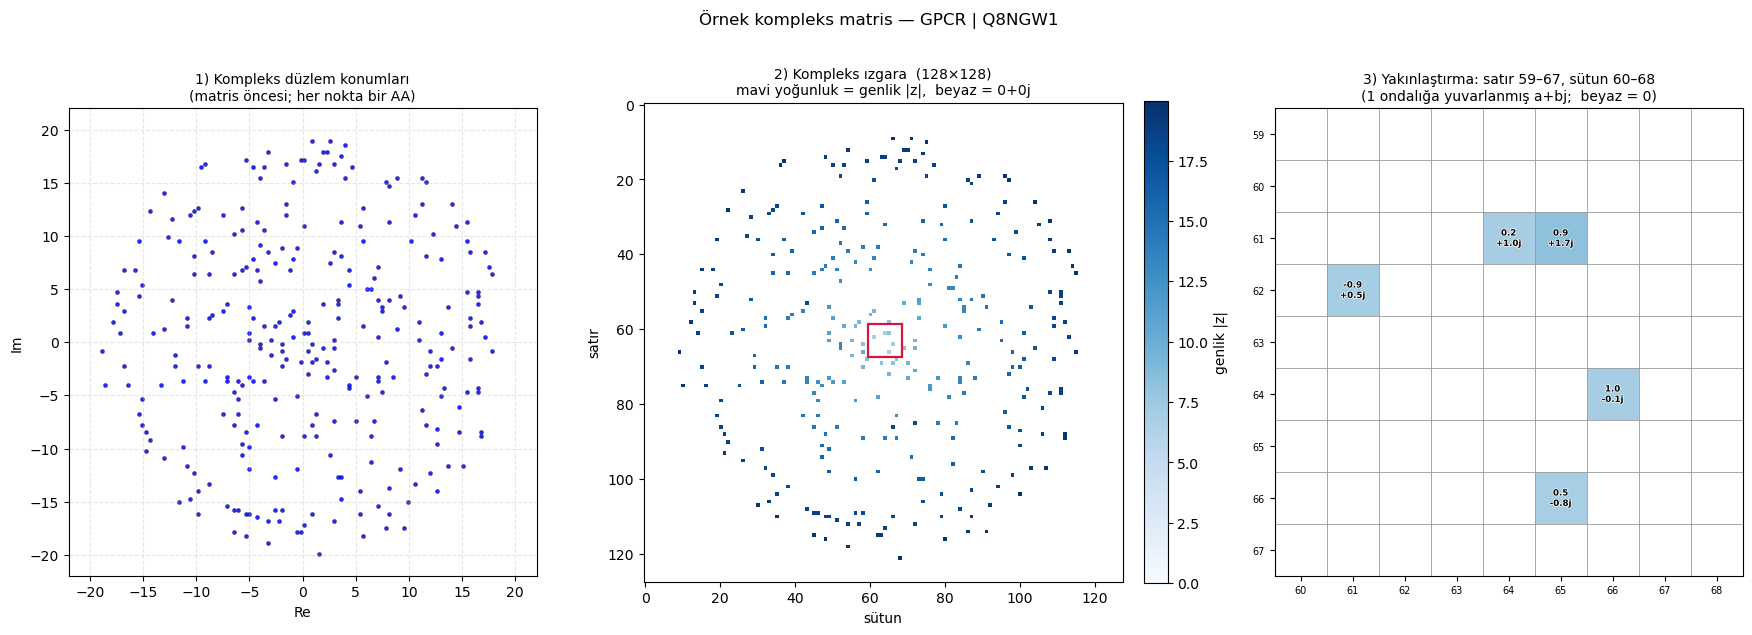

In [1]:
# =============================================================================
#   BİR DİZİ ÖRNEĞİ BASIMI
#   Panel 1 : Kompleks DÜZLEM konumları (matris öncesi)
#   Panel 2 : Kompleks IZGARA (128×128)
#   Panel 3 : Yakınlaştırma (dolu hücrelerde a+bj)
# =============================================================================
import os
import sys
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib import cm, colors

# ---------------- AYARLAR ----------------
NPZ_YOLU  = os.path.join("2B_Temssil_kodlama", "egitim.npz")
ORNEK_IDX = 0
YAKIN_K   = 9             
GAMMA     = 0.6           
MAVI_TABAN = 0.22         
KAYDET    = "ornek_matris_sekil.png"

# ---------------- YARDIMCILAR ----------------
def dosyayi_ac(yol):
    yol = os.path.abspath(yol)
    try:
        if os.name == "nt": os.startfile(yol)             
        elif sys.platform == "darwin": subprocess.run(["open", yol])
        else: subprocess.run(["xdg-open", yol])
    except Exception as e:
        print(f"[uyari] acilamadi ({e}); elle: {yol}")

def notebook_mu():
    try:
        from IPython import get_ipython
        return get_ipython().__class__.__name__ == "ZMQInteractiveShell"
    except Exception:
        return False

def text_rengi(rgb_hucre):
    lum = 0.299 * rgb_hucre[0] + 0.587 * rgb_hucre[1] + 0.114 * rgb_hucre[2]
    return ("white", "black") if lum < 0.55 else ("black", "white")   

def sacilim_noktalari(Xi, lim, px):
    """Izgaradaki dolu hucreleri kompleks duzlem konumlarina cevir (matris oncesi)."""
    sat, sut = np.nonzero(Xi)
    real = sut / (px - 1) * (2.0 * lim) - lim
    imag = lim - sat / (px - 1) * (2.0 * lim)
    return real, imag

# ---------------- YUKLE + YUVARLA ----------------
d = np.load(NPZ_YOLU, allow_pickle=True)
G = d["X"][ORNEK_IDX].astype(np.complex64)
G = (np.round(G.real, 1) + 1j * np.round(G.imag, 1)).astype(np.complex64)   
H, W = G.shape
y   = int(d["y"][ORNEK_IDX])   if "y"   in d.files else -1
acc = str(d["acc"][ORNEK_IDX]) if "acc" in d.files else "na"
lim = float(d["plot_lim"]) if "plot_lim" in d.files else 22.0
px  = int(d["tuval_px"])   if "tuval_px" in d.files else W
etiket = {0: "GPCR", 1: "KINASE"}.get(y, "?")

mag  = np.abs(G)
mmax = float(mag.max()) or 1.0
bos  = (mag == 0)

# mavi tonlama:
val = (mag / mmax) ** GAMMA
rgb = cm.Blues(MAVI_TABAN + (1.0 - MAVI_TABAN) * val)[..., :3]
rgb[bos] = [1.0, 1.0, 1.0]

print(f"Dosya: {NPZ_YOLU} | ornek {ORNEK_IDX} ({etiket}, {acc}) | sekil ({H},{W})")
print(f"Dolu hucre: {int((~bos).sum())}/{H*W} | max|z|={mmax:.2f} (yuvarlanmis)")

# ---------------- ŞEKİL: 3 PANEL ----------------
fig = plt.figure(figsize=(18, 6.4), facecolor="white")
gs  = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.12, 1.0], wspace=0.22)
ax1 = fig.add_subplot(gs[0]); ax2 = fig.add_subplot(gs[1]); ax3 = fig.add_subplot(gs[2])

# --- PANEL 1: KODLANAN KOMPLEKS DEĞERLER  (matris oncesi Düzlem)
real, imag = sacilim_noktalari(G, lim, px)
ax1.set_facecolor("white")
ax1.scatter(real, imag, s=9, c="blue", alpha=0.85, edgecolors="black", linewidths=0.2)
ax1.set_aspect("equal")
ax1.set_xlim(-lim, lim); ax1.set_ylim(-lim, lim)
ax1.grid(True, linestyle="--", alpha=0.3)
ax1.set_xlabel("Re"); ax1.set_ylabel("Im")
ax1.set_title("1) Kompleks düzlem konumları\n(matris öncesi; her nokta bir AA)", fontsize=10)

# --- PANEL 2: kompleks ızgara (128x128) ---
ax2.imshow(rgb, origin="upper", interpolation="nearest")
ax2.set_title(f"2) Kompleks ızgara  ({H}×{W})\n"
              f"mavi yoğunluk = genlik |z|,  beyaz = 0+0j", fontsize=10)
ax2.set_xlabel("sütun"); ax2.set_ylabel("satır")
sm = cm.ScalarMappable(norm=colors.Normalize(0, mmax), cmap="Blues")
cb = fig.colorbar(sm, ax=ax2, fraction=0.046, pad=0.04)
cb.set_label("genlik |z|")

# Yakınlaştırma penceresi dolu bolgeye ortalama
ii, jj = np.nonzero(~bos)
r0 = int(np.clip(int(np.median(ii)) - YAKIN_K // 2, 0, H - YAKIN_K))
c0 = int(np.clip(int(np.median(jj)) - YAKIN_K // 2, 0, W - YAKIN_K))
ax2.add_patch(plt.Rectangle((c0 - 0.5, r0 - 0.5), YAKIN_K, YAKIN_K,
                            fill=False, edgecolor="crimson", linewidth=1.6))

# --- PANEL 3: Yakınlaştırma (sayısal değer) ---
sub    = G[r0:r0 + YAKIN_K, c0:c0 + YAKIN_K]
subrgb = rgb[r0:r0 + YAKIN_K, c0:c0 + YAKIN_K]
ax3.imshow(subrgb, origin="upper", interpolation="nearest")
ax3.set_title(f"3) Yakınlaştırma: satır {r0}–{r0+YAKIN_K-1}, sütun {c0}–{c0+YAKIN_K-1}\n"
              f"(1 ondalığa yuvarlanmış a+bj;  beyaz = 0)", fontsize=10)
ax3.set_xticks(range(YAKIN_K)); ax3.set_xticklabels([str(c0 + j) for j in range(YAKIN_K)], fontsize=7)
ax3.set_yticks(range(YAKIN_K)); ax3.set_yticklabels([str(r0 + i) for i in range(YAKIN_K)], fontsize=7)
ax3.set_xticks(np.arange(-.5, YAKIN_K, 1), minor=True)
ax3.set_yticks(np.arange(-.5, YAKIN_K, 1), minor=True)
ax3.grid(which="minor", color="0.6", linewidth=0.6)
ax3.tick_params(which="minor", length=0)
for i in range(YAKIN_K):
    for j in range(YAKIN_K):
        z = sub[i, j]
        if z != 0:
            mrenk, krenk = text_rengi(subrgb[i, j])
            t = ax3.text(j, i, f"{z.real:.1f}\n{z.imag:+.1f}j",
                         ha="center", va="center", fontsize=6.2, color=mrenk, weight="bold")
            t.set_path_effects([pe.withStroke(linewidth=1.0, foreground=krenk)])

fig.suptitle(f"Örnek kompleks matris — {etiket} | {acc}", fontsize=12, y=1.0)
fig.subplots_adjust(top=0.86, left=0.05, right=0.98, bottom=0.10)

# ---------------- KAYDET ----------------
fig.savefig(KAYDET, dpi=150, bbox_inches="tight", facecolor="white")
print(f"[OK] Kaydedildi: {os.path.abspath(KAYDET)}")

if notebook_mu():
    from IPython.display import display
    display(fig)                 
    plt.close(fig)               
    dosyayi_ac(KAYDET)
else:
    dosyayi_ac(KAYDET)
    plt.show()

NOT: Protein dizilerini kompleks sayılara kodlama yöntemimizde ortaya çıkan değerlerin düzlemdeki gösterimi, insan algısı için üretilen gri tonlamalı (PNG) piksel görüntüleri yerine, kodlamada genliğe ve faza yüklenen biyolojik anlam matematiksel değeri korunarak ele alınması tercih edilmektedir. Böylece her örneğin kompleks düzlemdeki konumsal yapısı ve oluşturduğu matematiksel desen bozulmadan saklanmış; kodlanan protein örnekleri, iki boyutlu çerçeve biçiminde ve gerçek–sanal bileşenleriyle (kompleks değerler) doğrudan bir desen olarak 2B kompleks evrişimli ağa verilerek eğitilmiştir. Bu sayede sınıflandırma, suni bir piksel temsili üzerinden değil, dizilerin özgün faz–genlik yapısı korunarak gerçekleştirilmiştir.

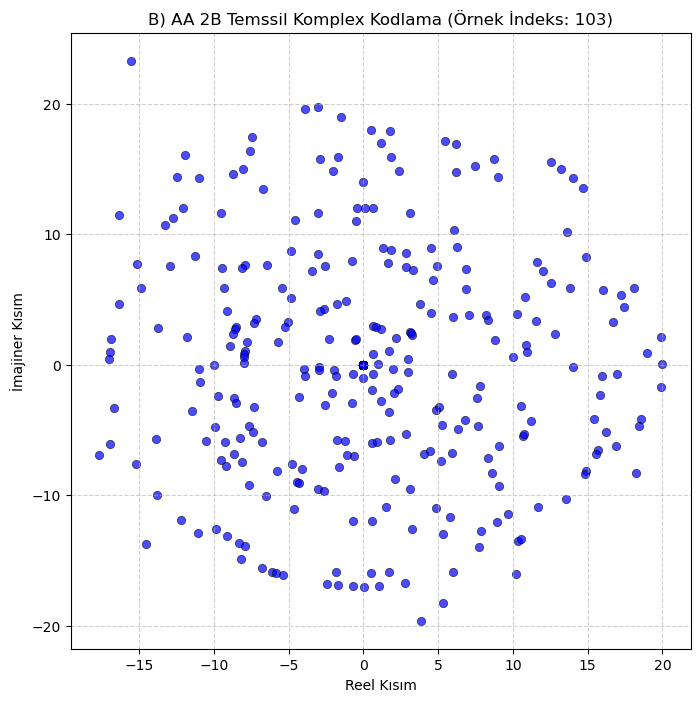

In [6]:
"""
======================================================================
AA Dizisi için 2B Komplex Temsil Yöntemiyle Kodlanan dosyadan bir örnek
======================================================================

"""
import matplotlib.pyplot as plt
import numpy as np

# 1. .npz dosyasının yolu
npz_file_path = "2B_Temssil_kodlama\egitim.npz"  # Dosya yolu
data = np.load(npz_file_path)

# 2. .npz içerisindeki ilk anahtar veri dizisini al
array_key = data.files[0]
complex_matrix = data[array_key]

# 3. Veri kümesindeki satırlardan (dizilerden) rastgele birini seç
random_idx = np.random.randint(0, complex_matrix.shape[0])
complex_numbers = complex_matrix[random_idx]

# 4. Reel ve İmajiner kısımları ayır
real_parts = complex_numbers.real
imaginary_parts = complex_numbers.imag

# 5. Grafiği oluştur
plt.figure(figsize=(8, 8))
plt.scatter(
    real_parts,
    imaginary_parts,
    color="blue",
    alpha=0.7,
    edgecolors="k",
    linewidth=0.5,
)

plt.xlabel("Reel Kısım")
plt.ylabel("İmajiner Kısım")
plt.title(f"B) AA 2B Temssil Komplex Kodlama (Örnek İndeks: {random_idx})")
plt.grid(True, linestyle="--", alpha=0.6)

# Yüksek kalitede kaydet 
plt.savefig("high_quality_plots.png", dpi=600, bbox_inches="tight")

plt.show()

### ADIM 2. Karmaşık Değerli 2B Evrişimli Sinir Ağları ile Protein/AA 2B Kompleks Temsillerin Sınıflandırılması
- Karmaşık Değerli 2B Evrişimli Sinir Ağları ile proteinlerin 2B kompleks temsilleri kullanılarak protein sınıflandırılması yapılmaktadır

In [5]:
# =============================================================================
#   2B EVRİŞİMLİ KOMPLEKS DEĞERLİ YSA — 2B KDEYSA  (TAM KOMPLEKS )
#
#      Akış:  10-FOLD CV  +  FİNAL MODEL  +  TEST
#
#   GİRDİ  : 2B_Temssil_kodlama.npz   (X = kompleks ızgara)
#
#   BU SÜRÜMDEKİ DEĞİŞİKLİKLER
#     (a) Evrişim sonrası 
#         Kompleks öznitelik haritası FAZ KORUNARAK düzleştirilir; tam-bağlantılı
#         katmanlar KOMPLEKS DEĞERLİ tasarlanır (KarmasikYogun + ModReLU/komplex_tanh
#         + KarmasikKatmanNorm + KarmasikDropout). Gömü (embedding) kompleks kalır;
#         prototip enerji başlığı kompleks mesafe (|z-p|²) üzerinden çalışır.
#         → Boru hattı uçtan uca komplekstir; hiçbir aşamada reel metrik uzaya
#           erken geçiş yoktur.
#
#   NOTLAR
#     * Girdi GERÇEKTEN komplekstir.
#     * Fold bölünmesi SPLIT_SEED=42 ile; reel ağ da AYNI tohumu kullandığından fold
#       üyelikleri iki ağda AYNIDIR (eşleştirilmiş istatistiksel test için gereklidir).
# 
# =============================================================================

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"]  = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
import warnings; warnings.filterwarnings("ignore")
import logging; logging.getLogger("tensorflow").setLevel(logging.ERROR)

import random

import numpy as np
import pandas as pd
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_recall_fscore_support)
from tensorflow.keras import Model, layers
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical


# =============================================================================
#   SABİTLER
# =============================================================================
NPZ_DIR    = "2B_Temssil_kodlama"
EGITIM_NPZ = os.path.join(NPZ_DIR, "egitim.npz")
TEST_NPZ   = os.path.join(NPZ_DIR, "test.npz")
RAPOR_XLSX = "2d_kompleks_sonuc.xlsx"

CLASS_MAP    = {"gpcr": 0, "kinase": 1}
SINIF_ADLARI = {0: "GPCR", 1: "Kinase"}
SINIF_SAYISI = 2

N_SPLITS      = 10
EPOCHS        = 120
BATCH_SIZE    = 16
OGRENME_ORANI = 1e-4
WEIGHT_DECAY  = 1e-4
CLIP_NORM     = 0.5

LAMBDA_CENTER_HEDEF     = 0.02
LAMBDA_CENTER_BASLANGIC = 0.0
LAMBDA_WARMUP_EPOCH     = 5
LABEL_SMOOTHING         = 0.02

FILTRELER      = (8, 16)          # 
KAFA_NORONLARI = (128, 64)        #
DROPOUT_KAFA   = (0.4, 0.3)       

# --- TOHUM: fold bölünmesi ORTAK tohum 
SPLIT_SEED = 42
RUN_SEED   = SPLIT_SEED

IMG_H = IMG_W = None


def set_seed(s):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(s); np.random.seed(s); random.seed(s)


set_seed(RUN_SEED)

print(f"[INFO] SPLIT_SEED / RUN_SEED : {SPLIT_SEED}")
print(f"[INFO] λ_center hedef        : {LAMBDA_CENTER_HEDEF} (warmup: {LAMBDA_WARMUP_EPOCH} epoch)")
print(f"[INFO] Kafa                  : kompleks düzleştir → KarmasikYogun{KAFA_NORONLARI} "
      f"→ kompleks prototip enerji (logit = -E)")


# =============================================================================
#   KOMPLEKS AKTİVASYONLAR
# =============================================================================
def komplex_tanh(z):
    return tf.complex(tf.math.tanh(tf.math.real(z)),
                      tf.math.tanh(tf.math.imag(z)))


class ModReLU(layers.Layer):
    """f(z) = ReLU(|z| + b) · (z / |z|)   —  genliğe eşikli, fazı koruyan aktivasyon"""
    def __init__(self, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        self.b = self.add_weight(shape=(int(input_shape[-1]),),
                                 initializer="zeros", trainable=True, name="b")

    def call(self, z):
        genlik  = tf.abs(z)
        katsayi = tf.nn.relu(genlik + self.b) / (genlik + self.eps)
        return tf.cast(katsayi, z.dtype) * z


# =============================================================================
#   COMPLEX BATCH NORM  (evrişim blokları için — kovaryans beyazlatma)
# =============================================================================
class ComplexBatchNorm(layers.Layer):
    def __init__(self, momentum=0.99, epsilon=1e-4, **kwargs):
        super().__init__(**kwargs); self.momentum = momentum; self.epsilon = epsilon

    def build(self, input_shape):
        C = int(input_shape[-1])
        self.gamma_rr = self.add_weight(shape=(C,), initializer='ones',  trainable=True,  name='g_rr')
        self.gamma_ii = self.add_weight(shape=(C,), initializer='ones',  trainable=True,  name='g_ii')
        self.gamma_ri = self.add_weight(shape=(C,), initializer='zeros', trainable=True,  name='g_ri')
        self.beta_r   = self.add_weight(shape=(C,), initializer='zeros', trainable=True,  name='b_r')
        self.beta_i   = self.add_weight(shape=(C,), initializer='zeros', trainable=True,  name='b_i')
        self.mov_mu_r = self.add_weight(shape=(C,), initializer='zeros', trainable=False, name='m_mu_r')
        self.mov_mu_i = self.add_weight(shape=(C,), initializer='zeros', trainable=False, name='m_mu_i')
        self.mov_Vrr  = self.add_weight(shape=(C,), initializer='ones',  trainable=False, name='m_Vrr')
        self.mov_Vii  = self.add_weight(shape=(C,), initializer='ones',  trainable=False, name='m_Vii')
        self.mov_Vri  = self.add_weight(shape=(C,), initializer='zeros', trainable=False, name='m_Vri')

    def call(self, x, training=None):
        xr = tf.math.real(x); xi = tf.math.imag(x)
        if training:
            mu_r = tf.reduce_mean(xr, axis=[0, 1, 2]); mu_i = tf.reduce_mean(xi, axis=[0, 1, 2])
            xr_c = xr - mu_r; xi_c = xi - mu_i
            Vrr = tf.reduce_mean(xr_c ** 2, axis=[0, 1, 2]) + self.epsilon
            Vii = tf.reduce_mean(xi_c ** 2, axis=[0, 1, 2]) + self.epsilon
            Vri = tf.reduce_mean(xr_c * xi_c, axis=[0, 1, 2])
            m = self.momentum
            self.mov_mu_r.assign(m * self.mov_mu_r + (1 - m) * mu_r)
            self.mov_mu_i.assign(m * self.mov_mu_i + (1 - m) * mu_i)
            self.mov_Vrr.assign( m * self.mov_Vrr  + (1 - m) * Vrr)
            self.mov_Vii.assign( m * self.mov_Vii  + (1 - m) * Vii)
            self.mov_Vri.assign( m * self.mov_Vri  + (1 - m) * Vri)
        else:
            mu_r = self.mov_mu_r; mu_i = self.mov_mu_i
            Vrr = self.mov_Vrr; Vii = self.mov_Vii; Vri = self.mov_Vri
            xr_c = xr - mu_r; xi_c = xi - mu_i
        det = tf.maximum(Vrr * Vii - Vri ** 2, self.epsilon)
        s = tf.sqrt(det); t = tf.sqrt(Vrr + Vii + 2.0 * s); inv = 1.0 / (s * t + self.epsilon)
        Wrr = inv * (Vii + s); Wii = inv * (Vrr + s); Wri = -inv * Vri
        yr = Wrr * xr_c + Wri * xi_c; yi = Wri * xr_c + Wii * xi_c
        out_r = self.gamma_rr * yr + self.gamma_ri * yi + self.beta_r
        out_i = self.gamma_ri * yr + self.gamma_ii * yi + self.beta_i
        return tf.complex(out_r, out_i)


# =============================================================================
#   KOMPLEKS KATMAN NORM & KOMPLEKS DROPOUT 
# =============================================================================
class KarmasikKatmanNorm(layers.Layer):
    def __init__(self, eps=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.gamma = self.add_weight(shape=(2, d), initializer="ones",
                                     trainable=True, name="gamma")
        self.beta  = self.add_weight(shape=(2, d), initializer="zeros",
                                     trainable=True, name="beta")

    def call(self, z):
        zr, zi = tf.math.real(z), tf.math.imag(z)
        x = tf.stack([zr, zi], axis=1)
        ort = tf.reduce_mean(x, axis=[1, 2], keepdims=True)
        var = tf.reduce_mean(tf.square(x - ort), axis=[1, 2], keepdims=True)
        x_hat = (x - ort) / tf.sqrt(var + self.eps)
        x_hat = x_hat * self.gamma[None, ...] + self.beta[None, ...]
        return tf.complex(x_hat[:, 0, :], x_hat[:, 1, :])


class KarmasikDropout(layers.Layer):
    def __init__(self, oran=0.2, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.oran = float(oran)
        self.seed = int(seed)
        self.rng  = None

    def build(self, input_shape):
        self.rng = tf.random.Generator.from_seed(self.seed)

    def call(self, z, training=False):
        if (not training) or self.oran <= 0.0:
            return z
        tutma = 1.0 - self.oran
        sekil = tf.shape(tf.math.real(z))
        maske = self.rng.uniform(sekil, dtype=tf.float32)
        maske = tf.cast(maske < tutma, tf.float32) / tutma
        maske = tf.cast(maske, z.dtype)
        return z * maske


# =============================================================================
#   KOMPLEKS CONV2D (L2 dahil) & AVG POOL
# ============================================================================
class KarmasikConv2D(layers.Layer):
    def __init__(self, filters, kernel_size, activation=None, l2=0.0, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters; self.kernel_size = kernel_size
        self.activation = activation; self.l2 = float(l2); self.seed = int(seed)

    def build(self, input_shape):
        kh, kw = self.kernel_size; c_in = int(input_shape[-1])
        init = tf.keras.initializers.GlorotUniform(seed=self.seed); olcek = 1.0 / np.sqrt(2.0)
        reg  = tf.keras.regularizers.L2(self.l2) if self.l2 > 0 else None

        def si(shape, dtype=None):
            return tf.cast(init(shape, dtype=dtype), tf.float32) * olcek

        ks = (kh, kw, c_in, self.filters)
        self.kr = self.add_weight(shape=ks, initializer=si, regularizer=reg, trainable=True, name="kr")
        self.ki = self.add_weight(shape=ks, initializer=si, regularizer=reg, trainable=True, name="ki")
        self.br = self.add_weight(shape=(self.filters,), initializer="zeros", trainable=True, name="br")
        self.bi = self.add_weight(shape=(self.filters,), initializer="zeros", trainable=True, name="bi")

    def call(self, x):
        xr, xi = tf.math.real(x), tf.math.imag(x)
        yr = (tf.nn.conv2d(xr, self.kr, [1, 1, 1, 1], "SAME")
              - tf.nn.conv2d(xi, self.ki, [1, 1, 1, 1], "SAME") + self.br)
        yi = (tf.nn.conv2d(xr, self.ki, [1, 1, 1, 1], "SAME")
              + tf.nn.conv2d(xi, self.kr, [1, 1, 1, 1], "SAME") + self.bi)
        z = tf.complex(yr, yi)
        return self.activation(z) if self.activation else z


class KarmasikAvgPool2D(layers.Layer):
    def __init__(self, pool_size=2, **kwargs):
        super().__init__(**kwargs); self.pool_size = pool_size

    def call(self, x):
        p = self.pool_size
        return tf.complex(tf.nn.avg_pool2d(tf.math.real(x), p, p, "VALID"),
                          tf.nn.avg_pool2d(tf.math.imag(x), p, p, "VALID"))


# ============================================================================
#   KOMPLEKS DÜZLEŞTİRME  (faz korunur)
#   (B, H, W, C) → (B, H*W*C) kompleks; Re/Im aynı sırayla eşlenir.
# =============================================================================
class KarmasikDuzlestir(layers.Layer):
    def build(self, input_shape):
        flat = 1
        for d in input_shape[1:]:
            flat *= int(d)
        self.flat_dim = flat
        super().build(input_shape)

    def call(self, x):
        b  = tf.shape(x)[0]
        xr = tf.reshape(tf.math.real(x), [b, self.flat_dim])
        xi = tf.reshape(tf.math.imag(x), [b, self.flat_dim])
        return tf.complex(xr, xi)

    def compute_output_shape(self, input_shape):
        flat = 1
        for d in input_shape[1:]:
            flat *= int(d)
        return (input_shape[0], flat)


# =========================================================================
#   KOMPLEKS YOĞUN KATMAN  (L2 dahil)
# ============================================================================
class KarmasikYogun(layers.Layer):
    def __init__(self, noron_sayisi, aktivasyon=None, l2=0.0, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.noron_sayisi = int(noron_sayisi)
        self.aktivasyon   = aktivasyon
        self.l2           = float(l2)
        self.seed         = int(seed)

    def build(self, input_shape):
        d    = int(input_shape[-1])
        init = tf.keras.initializers.GlorotUniform(seed=self.seed)
        k    = 1.0 / np.sqrt(2.0)

        def si(shape, dtype=None):
            return tf.cast(init(shape, dtype=dtype), tf.float32) * k

        reg = tf.keras.regularizers.L2(self.l2) if self.l2 > 0 else None

        self.wr = self.add_weight(shape=(d, self.noron_sayisi), initializer=si,
                                  regularizer=reg, trainable=True, name="wr")
        self.wi = self.add_weight(shape=(d, self.noron_sayisi), initializer=si,
                                  regularizer=reg, trainable=True, name="wi")
        self.br = self.add_weight(shape=(self.noron_sayisi,), initializer="zeros",
                                  trainable=True, name="br")
        self.bi = self.add_weight(shape=(self.noron_sayisi,), initializer="zeros",
                                  trainable=True, name="bi")

    def call(self, x):
        xr, xi = tf.math.real(x), tf.math.imag(x)
        yr = tf.matmul(xr, self.wr) - tf.matmul(xi, self.wi) + self.br
        yi = tf.matmul(xr, self.wi) + tf.matmul(xi, self.wr) + self.bi
        y  = tf.complex(yr, yi)
        return self.aktivasyon(y) if self.aktivasyon is not None else y


# ==========================================================================
#   PROTOTİP ENERJİ BAŞLIĞI  (KOMPLEKS mesafe)  +  KAYIPLAR
# ============================================================================
class PrototipEnerjiBasligi(layers.Layer):
    def __init__(self, sinif_sayisi=2, prototip_ogrenilsin=True,
                 stddev=0.05, seed=0, **kwargs):
        super().__init__(**kwargs)
        self.sinif_sayisi        = int(sinif_sayisi)
        self.prototip_ogrenilsin = bool(prototip_ogrenilsin)
        self.stddev              = float(stddev)
        self.seed                = int(seed)

    def build(self, input_shape):
        d = int(input_shape[-1])
        self.prototip_real = self.add_weight(
            shape=(self.sinif_sayisi, d),
            initializer=tf.keras.initializers.RandomNormal(stddev=self.stddev, seed=self.seed),
            trainable=self.prototip_ogrenilsin, name="prototip_real")
        self.prototip_imaj = self.add_weight(
            shape=(self.sinif_sayisi, d),
            initializer=tf.keras.initializers.RandomNormal(stddev=self.stddev, seed=self.seed + 1),
            trainable=self.prototip_ogrenilsin, name="prototip_imaj")

    def call(self, z):
        zr = tf.expand_dims(tf.math.real(z), axis=1)
        zi = tf.expand_dims(tf.math.imag(z), axis=1)
        pr = tf.expand_dims(self.prototip_real, axis=0)
        pi = tf.expand_dims(self.prototip_imaj, axis=0)
        enerji = tf.reduce_sum((zr - pr) ** 2 + (zi - pi) ** 2, axis=-1)
        return -enerji, enerji


def wirtinger_ce_kaybi(logit, y_onehot, label_smoothing=0.0):
    y = tf.cast(y_onehot, tf.float32)
    if label_smoothing > 0.0:
        C = tf.cast(tf.shape(y)[-1], tf.float32)
        y = y * (1.0 - label_smoothing) + label_smoothing / C
    log_p = tf.nn.log_softmax(logit, axis=-1)
    return -tf.reduce_mean(tf.reduce_sum(y * log_p, axis=-1))


def wirtinger_center_kaybi(z, y_onehot, proto_real, proto_imaj):
    y  = tf.cast(y_onehot, tf.float32)
    pr = tf.matmul(y, proto_real)
    pi = tf.matmul(y, proto_imaj)
    zr = tf.math.real(z)
    zi = tf.math.imag(z)
    kare_mesafe = tf.reduce_sum((zr - pr) ** 2 + (zi - pi) ** 2, axis=-1)
    return 0.5 * tf.reduce_mean(kare_mesafe)


# ===========================================================================
#   KODLAYICI  (2 kompleks evrişim bloğu + kompleks düzleştir + kompleks yoğun
# =============================================================================
def build_encoder(seed=0):
    f1, f2 = FILTRELER
    h1, h2 = KAFA_NORONLARI
    d1, d2 = DROPOUT_KAFA

    inp = Input(shape=(IMG_H, IMG_W, 1), dtype=tf.complex64)

    # --- Kompleks evrişim blokları ---
    x = KarmasikConv2D(f1, (3, 3), activation=komplex_tanh, l2=WEIGHT_DECAY,
                       seed=seed,     name='cconv1')(inp)
    x = ComplexBatchNorm(name='cbn1')(x); x = KarmasikAvgPool2D(2)(x)
    x = KarmasikConv2D(f2, (3, 3), activation=komplex_tanh, l2=WEIGHT_DECAY,
                       seed=seed + 1, name='cconv2')(x)
    x = ComplexBatchNorm(name='cbn2')(x); x = KarmasikAvgPool2D(2)(x)

    # --- Kompleks düzleştirme (faz korunur) ---
    x = KarmasikDuzlestir(name='kompleks_duzlestir')(x)

    # --- Kompleks tam-bağlantılı kafa ---
    x = KarmasikYogun(h1, aktivasyon=None, l2=WEIGHT_DECAY,
                      seed=seed + 2, name='kyogun_1')(x)
    x = ModReLU(name='modrelu_1')(x)
    x = KarmasikKatmanNorm(name='knorm_1')(x)
    x = KarmasikDropout(oran=d1, seed=seed + 2, name='kdrop_1')(x)

    z = KarmasikYogun(h2, aktivasyon=komplex_tanh, l2=WEIGHT_DECAY,
                      seed=seed + 3, name='gomulum')(x)
    z = KarmasikKatmanNorm(name='knorm_2')(z)
    z = KarmasikDropout(oran=d2, seed=seed + 3, name='kdrop_2')(z)

    return Model(inp, z, name="Kompleks2DCNNKodlayici")


# =============================================================================
#   EĞİTİCİ
# =============================================================================
class KarmasikEgitici(Model):
    def __init__(self, kodlayici, baslik, lambda_center_baslangic=0.0, label_smoothing=0.02):
        super().__init__()
        self.kodlayici = kodlayici; self.baslik = baslik
        self.lambda_center = tf.Variable(float(lambda_center_baslangic), trainable=False,
                                         dtype=tf.float32, name="lambda_center")
        self.label_smoothing = float(label_smoothing)
        self.acc = tf.keras.metrics.CategoricalAccuracy(name="dogruluk")

    @property
    def metrics(self):
        return [self.acc]

    def call(self, x, training=False):
        z = self.kodlayici(x, training=training)
        logit, _ = self.baslik(z)
        return tf.nn.softmax(logit)

    def _kayip_hesapla(self, x, y, training=False):
        z = self.kodlayici(x, training=training)
        tf.debugging.assert_type(z, tf.complex64)
        logit, _ = self.baslik(z); prob = tf.nn.softmax(logit)
        kayip_ce = wirtinger_ce_kaybi(logit, y, self.label_smoothing)
        kayip_center = wirtinger_center_kaybi(
            z, y, self.baslik.prototip_real, self.baslik.prototip_imaj)
        kayip_reg = tf.add_n(self.kodlayici.losses) if self.kodlayici.losses else 0.0
        toplam = kayip_ce + self.lambda_center * kayip_center + kayip_reg
        return toplam, kayip_ce, kayip_center, kayip_reg, prob

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            toplam, kayip_ce, kayip_center, kayip_reg, prob = self._kayip_hesapla(x, y, training=True)
        dv = self.kodlayici.trainable_variables + self.baslik.trainable_variables
        g  = tape.gradient(toplam, dv)
        g  = [gi if gi is not None else tf.zeros_like(v) for gi, v in zip(g, dv)]
        g, _ = tf.clip_by_global_norm(g, CLIP_NORM)
        self.optimizer.apply_gradients(zip(g, dv))
        self.acc.update_state(y, prob)
        return {"kayip": toplam, "kayip_ce": kayip_ce, "kayip_center": kayip_center,
                "kayip_reg": kayip_reg, "lambda_center": self.lambda_center,
                "dogruluk": self.acc.result()}

    def test_step(self, data):
        x, y = data
        toplam, kayip_ce, kayip_center, kayip_reg, prob = self._kayip_hesapla(x, y, training=False)
        self.acc.update_state(y, prob)
        return {"kayip": toplam, "kayip_ce": kayip_ce, "kayip_center": kayip_center,
                "kayip_reg": kayip_reg, "lambda_center": self.lambda_center,
                "dogruluk": self.acc.result()}


class LambdaCenterScheduler(tf.keras.callbacks.Callback):
    def __init__(self, baslangic=0.0, hedef=0.02, warmup_epoch=5, verbose=0):
        super().__init__()
        self.baslangic = float(baslangic); self.hedef = float(hedef)
        self.warmup_epoch = int(warmup_epoch); self.verbose = int(verbose)

    def on_epoch_begin(self, epoch, logs=None):
        if self.warmup_epoch <= 0 or epoch >= self.warmup_epoch:
            yeni = self.hedef
        else:
            yeni = self.baslangic + (self.hedef - self.baslangic) * (epoch / self.warmup_epoch)
        self.model.lambda_center.assign(yeni)
        if self.verbose:
            print(f"  [λ_center] Epoch {epoch}: {yeni:.4f}")


def callback_listesi_olustur(reduce_lr_patience=10, early_stop_patience=25,
                             reduce_verbose=0, early_verbose=0, scheduler_verbose=0):
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_dogruluk", mode="max",
            patience=early_stop_patience, restore_best_weights=True, verbose=early_verbose),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_kayip_ce", mode="min", factor=0.5,
            patience=reduce_lr_patience, min_lr=1e-5, verbose=reduce_verbose),
        tf.keras.callbacks.TerminateOnNaN(),
        LambdaCenterScheduler(LAMBDA_CENTER_BASLANGIC, LAMBDA_CENTER_HEDEF,
                              LAMBDA_WARMUP_EPOCH, verbose=scheduler_verbose),
    ]


def modeli_kur(seed=0):
    kodlayici = build_encoder(seed=seed)
    baslik    = PrototipEnerjiBasligi(sinif_sayisi=SINIF_SAYISI, seed=seed + 100, name="baslik")
    egitici   = KarmasikEgitici(kodlayici, baslik, LAMBDA_CENTER_BASLANGIC, LABEL_SMOOTHING)
    egitici.compile(optimizer=Adam(learning_rate=OGRENME_ORANI))
    egitici.build(input_shape=(None, IMG_H, IMG_W, 1))
    return egitici


# ============================================================================
#   VERİ  (npz kompleks ızgaralar)
# =============================================================================
def veri_yukle_npz(yol):
    d = np.load(yol, allow_pickle=True)
    X = d["X"].astype(np.complex64)
    y = d["y"].astype(int)
    return X, y


print("[INFO] Veri yükleniyor (npz)...")
X_full_train, y_full_train_int = veri_yukle_npz(EGITIM_NPZ)
X_test,       y_test_int       = veri_yukle_npz(TEST_NPZ)

# Genlik ölçekleme (faz korunur)
olcek = float(np.abs(X_full_train).max())
if olcek == 0.0:
    olcek = 1.0
X_full_train = (X_full_train / olcek).astype(np.complex64)[..., None]
X_test       = (X_test       / olcek).astype(np.complex64)[..., None]

IMG_H, IMG_W = int(X_full_train.shape[1]), int(X_full_train.shape[2])

y_full_train = to_categorical(y_full_train_int, SINIF_SAYISI).astype(np.float32)
y_test       = to_categorical(y_test_int,       SINIF_SAYISI).astype(np.float32)

print(f"\n=== VERİ BİLGİSİ ===")
print(f"Izgara     : {IMG_H}x{IMG_W} | genlik ölçeği (bölen): {olcek:.4f}")
print(f"CV havuzu  : {X_full_train.shape[0]} "
      f"(GPCR={np.sum(y_full_train_int == 0)}, Kinase={np.sum(y_full_train_int == 1)})")
print(f"Final test : {X_test.shape[0]} "
      f"(GPCR={np.sum(y_test_int == 0)}, Kinase={np.sum(y_test_int == 1)})")
print("====================\n")


# ============================================================================
#   10-FOLD CV   (fold bölünmesi 
# =============================================================================
skf            = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SPLIT_SEED)
fold_sonuclari = []
histories      = []

for fold_no, (tr_idx, vl_idx) in enumerate(
        skf.split(X_full_train, y_full_train_int), start=1):

    print(f"\n{'=' * 48}\n  FOLD {fold_no}/{N_SPLITS}\n{'=' * 48}")

    X_tr, X_vl = X_full_train[tr_idx], X_full_train[vl_idx]
    y_tr, y_vl = y_full_train[tr_idx], y_full_train[vl_idx]
    y_vl_int   = y_full_train_int[vl_idx]

    fold_seed = RUN_SEED + fold_no * 100
    set_seed(fold_seed)
    model   = modeli_kur(seed=fold_seed)
    history = model.fit(X_tr, y_tr, validation_data=(X_vl, y_vl),
                        epochs=EPOCHS, batch_size=BATCH_SIZE,
                        callbacks=callback_listesi_olustur(), verbose=0)
    histories.append(history.history)

    y_vl_pred = np.argmax(model.predict(X_vl, verbose=0), axis=1)
    fold_acc  = accuracy_score(y_vl_int, y_vl_pred)

    prec_cls, rec_cls, f1_cls, sup_cls = precision_recall_fscore_support(
        y_vl_int, y_vl_pred, labels=[0, 1], average=None, zero_division=0)
    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
        y_vl_int, y_vl_pred, average="macro", zero_division=0)

    h = history.history
    fold_sonuclari.append({
        "fold": fold_no, "acc": fold_acc, "macro_f1": macro_f1,
        "macro_precision": macro_prec, "macro_recall": macro_rec,
        "gpcr_precision": prec_cls[0], "gpcr_recall": rec_cls[0],
        "gpcr_f1": f1_cls[0], "gpcr_support": sup_cls[0],
        "kinase_precision": prec_cls[1], "kinase_recall": rec_cls[1],
        "kinase_f1": f1_cls[1], "kinase_support": sup_cls[1],
        "best_val_loss":   float(np.nanmin(h["val_kayip"])),
        "best_val_acc":    float(np.nanmax(h["val_dogruluk"])),
        "best_val_ce":     float(np.nanmin(h["val_kayip_ce"])),
        "best_val_center": float(np.nanmin(h["val_kayip_center"])),
        "epoch_sayisi":    len(h["kayip"]),
    })

    print(f"Fold Acc      : {fold_acc:.4f}  |  Macro F1  : {macro_f1:.4f}")
    print(f"GPCR F1       : {f1_cls[0]:.4f}  |  Kinase F1 : {f1_cls[1]:.4f}")
    print(f"Best Val Acc  : {fold_sonuclari[-1]['best_val_acc']:.4f}  |  "
          f"Best Val CE : {fold_sonuclari[-1]['best_val_ce']:.4f}")
    print(f"Epoch sayısı  : {fold_sonuclari[-1]['epoch_sayisi']}")


cv_df = pd.DataFrame(fold_sonuclari)

print("\n" + "=" * 55)
print("  10-FOLD CV ÖZET  (2D-Conv Kompleks — tam kompleks kafa)")
print("=" * 55)
print(cv_df[["fold", "acc", "macro_f1", "gpcr_f1", "kinase_f1",
             "best_val_acc", "best_val_ce", "epoch_sayisi"]].round(4).to_string(index=False))

print("\n--- CV ORTALAMA ± STD ---")
for k in ["acc", "macro_f1", "gpcr_f1", "kinase_f1",
          "best_val_loss", "best_val_acc", "best_val_ce", "best_val_center", "epoch_sayisi"]:
    print(f"  {k:18s}: {cv_df[k].mean():.4f} ± {cv_df[k].std(ddof=1):.4f}")


# =============================================================================
#   FİNAL MODEL  
# =============================================================================
print("\n" + "=" * 55)
print("  FİNAL MODEL EĞİTİMİ")
print("=" * 55)

final_seed   = RUN_SEED + 9999
median_epoch = int(np.median(cv_df["epoch_sayisi"]))
print(f"[INFO] CV medyan epoch : {median_epoch}")

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=SPLIT_SEED)
(final_tr_idx, final_vl_idx), = sss.split(X_full_train, y_full_train_int)
X_ftr, X_fvl = X_full_train[final_tr_idx], X_full_train[final_vl_idx]
y_ftr, y_fvl = y_full_train[final_tr_idx], y_full_train[final_vl_idx]

print(f"[INFO] Final train : {len(final_tr_idx)} "
      f"(GPCR={np.sum(y_full_train_int[final_tr_idx] == 0)}, "
      f"Kinase={np.sum(y_full_train_int[final_tr_idx] == 1)})")
print(f"[INFO] Final val   : {len(final_vl_idx)} "
      f"(GPCR={np.sum(y_full_train_int[final_vl_idx] == 0)}, "
      f"Kinase={np.sum(y_full_train_int[final_vl_idx] == 1)})")

set_seed(final_seed)
final_model = modeli_kur(seed=final_seed)
final_callbacks = callback_listesi_olustur(
    reduce_lr_patience=10, early_stop_patience=25,
    reduce_verbose=1, early_verbose=1, scheduler_verbose=1)
final_history = final_model.fit(
    X_ftr, y_ftr, validation_data=(X_fvl, y_fvl),
    epochs=median_epoch + 50, batch_size=BATCH_SIZE,
    shuffle=True, callbacks=final_callbacks, verbose=1)


# =============================================================================
#   TEST DEĞERLENDİRME
# =============================================================================
test_eval   = final_model.evaluate(X_test, y_test, verbose=0, return_dict=True)
y_test_prob = final_model.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)

test_cm  = confusion_matrix(y_test_int, y_test_pred, labels=[0, 1])
test_acc = accuracy_score(y_test_int, y_test_pred)

prec_t, rec_t, f1_t, sup_t = precision_recall_fscore_support(
    y_test_int, y_test_pred, labels=[0, 1], average=None, zero_division=0)
_, _, macro_f1_t, _ = precision_recall_fscore_support(
    y_test_int, y_test_pred, average="macro", zero_division=0)

print("\n" + "=" * 55)
print("  FİNAL TEST SONUCU  (2D-Conv Kompleks KDYSA — tam kompleks)")
print("=" * 55)
print("Confusion Matrix:")
print(f"              pred_GPCR   pred_Kinase")
print(f"  true_GPCR     {test_cm[0, 0]:5d}       {test_cm[0, 1]:5d}")
print(f"  true_Kinase   {test_cm[1, 0]:5d}       {test_cm[1, 1]:5d}")
print()
print(f"Test Accuracy        : {test_acc:.4f}")
print(f"Test Loss (toplam)   : {test_eval['kayip']:.4f}")
print(f"Test Wirtinger CE    : {test_eval['kayip_ce']:.4f}")
print(f"Test Wirtinger Cnt   : {test_eval['kayip_center']:.4f}")
print(f"Test Macro F1        : {macro_f1_t:.4f}")
print(f"GPCR   F1/P/R        : {f1_t[0]:.4f}/{prec_t[0]:.4f}/{rec_t[0]:.4f}  (N={sup_t[0]})")
print(f"Kinase F1/P/R        : {f1_t[1]:.4f}/{prec_t[1]:.4f}/{rec_t[1]:.4f}  (N={sup_t[1]})")


# =============================================================================
#   RAPOR
# =============================================================================
fold_metrikleri = cv_df[["fold", "acc", "macro_f1", "gpcr_f1", "kinase_f1",
                         "best_val_acc", "epoch_sayisi"]].copy()
fold_metrikleri.insert(0, "model", "2D_Kompleks_CNN")

ozet = pd.DataFrame([{
    "model":            "2D_Kompleks_CNN",
    "split_seed":       SPLIT_SEED,
    "izgara":           f"{IMG_H}x{IMG_W}",
    "cv_acc_ort":       float(cv_df["acc"].mean()),
    "cv_acc_std":       float(cv_df["acc"].std(ddof=1)),
    "cv_macrof1_ort":   float(cv_df["macro_f1"].mean()),
    "cv_macrof1_std":   float(cv_df["macro_f1"].std(ddof=1)),
    "test_acc":         float(test_acc),
    "test_macro_f1":    float(macro_f1_t),
}])

with pd.ExcelWriter(RAPOR_XLSX) as w:
    ozet.to_excel(w,            sheet_name="ozet",            index=False)
    fold_metrikleri.to_excel(w, sheet_name="fold_metrikleri", index=False)
    cv_df.to_excel(w,           sheet_name="cv_detay",         index=False)

print(f"\n[OK] Rapor kaydedildi: {RAPOR_XLSX}")
print(f"     CV acc = {cv_df['acc'].mean():.4f} ± {cv_df['acc'].std(ddof=1):.4f} | "
      f"Test acc = {test_acc:.4f}")

[INFO] SPLIT_SEED / RUN_SEED : 42
[INFO] λ_center hedef        : 0.02 (warmup: 5 epoch)
[INFO] Kafa                  : kompleks düzleştir → KarmasikYogun(128, 64) → kompleks prototip enerji (logit = -E)
[INFO] Veri yükleniyor (npz)...

=== VERİ BİLGİSİ ===
Izgara     : 128x128 | genlik ölçeği (bölen): 39.9993
CV havuzu  : 400 (GPCR=200, Kinase=200)
Final test : 200 (GPCR=100, Kinase=100)


  FOLD 1/10
Fold Acc      : 0.9750  |  Macro F1  : 0.9750
GPCR F1       : 0.9744  |  Kinase F1 : 0.9756
Best Val Acc  : 0.9750  |  Best Val CE : 0.0674
Epoch sayısı  : 47

  FOLD 2/10
Fold Acc      : 1.0000  |  Macro F1  : 1.0000
GPCR F1       : 1.0000  |  Kinase F1 : 1.0000
Best Val Acc  : 1.0000  |  Best Val CE : 0.0671
Epoch sayısı  : 26

  FOLD 3/10
Fold Acc      : 1.0000  |  Macro F1  : 1.0000
GPCR F1       : 1.0000  |  Kinase F1 : 1.0000
Best Val Acc  : 1.0000  |  Best Val CE : 0.0615
Epoch sayısı  : 35

  FOLD 4/10
Fold Acc      : 0.9750  |  Macro F1  : 0.9750
GPCR F1       : 0.9756  |  Kinase

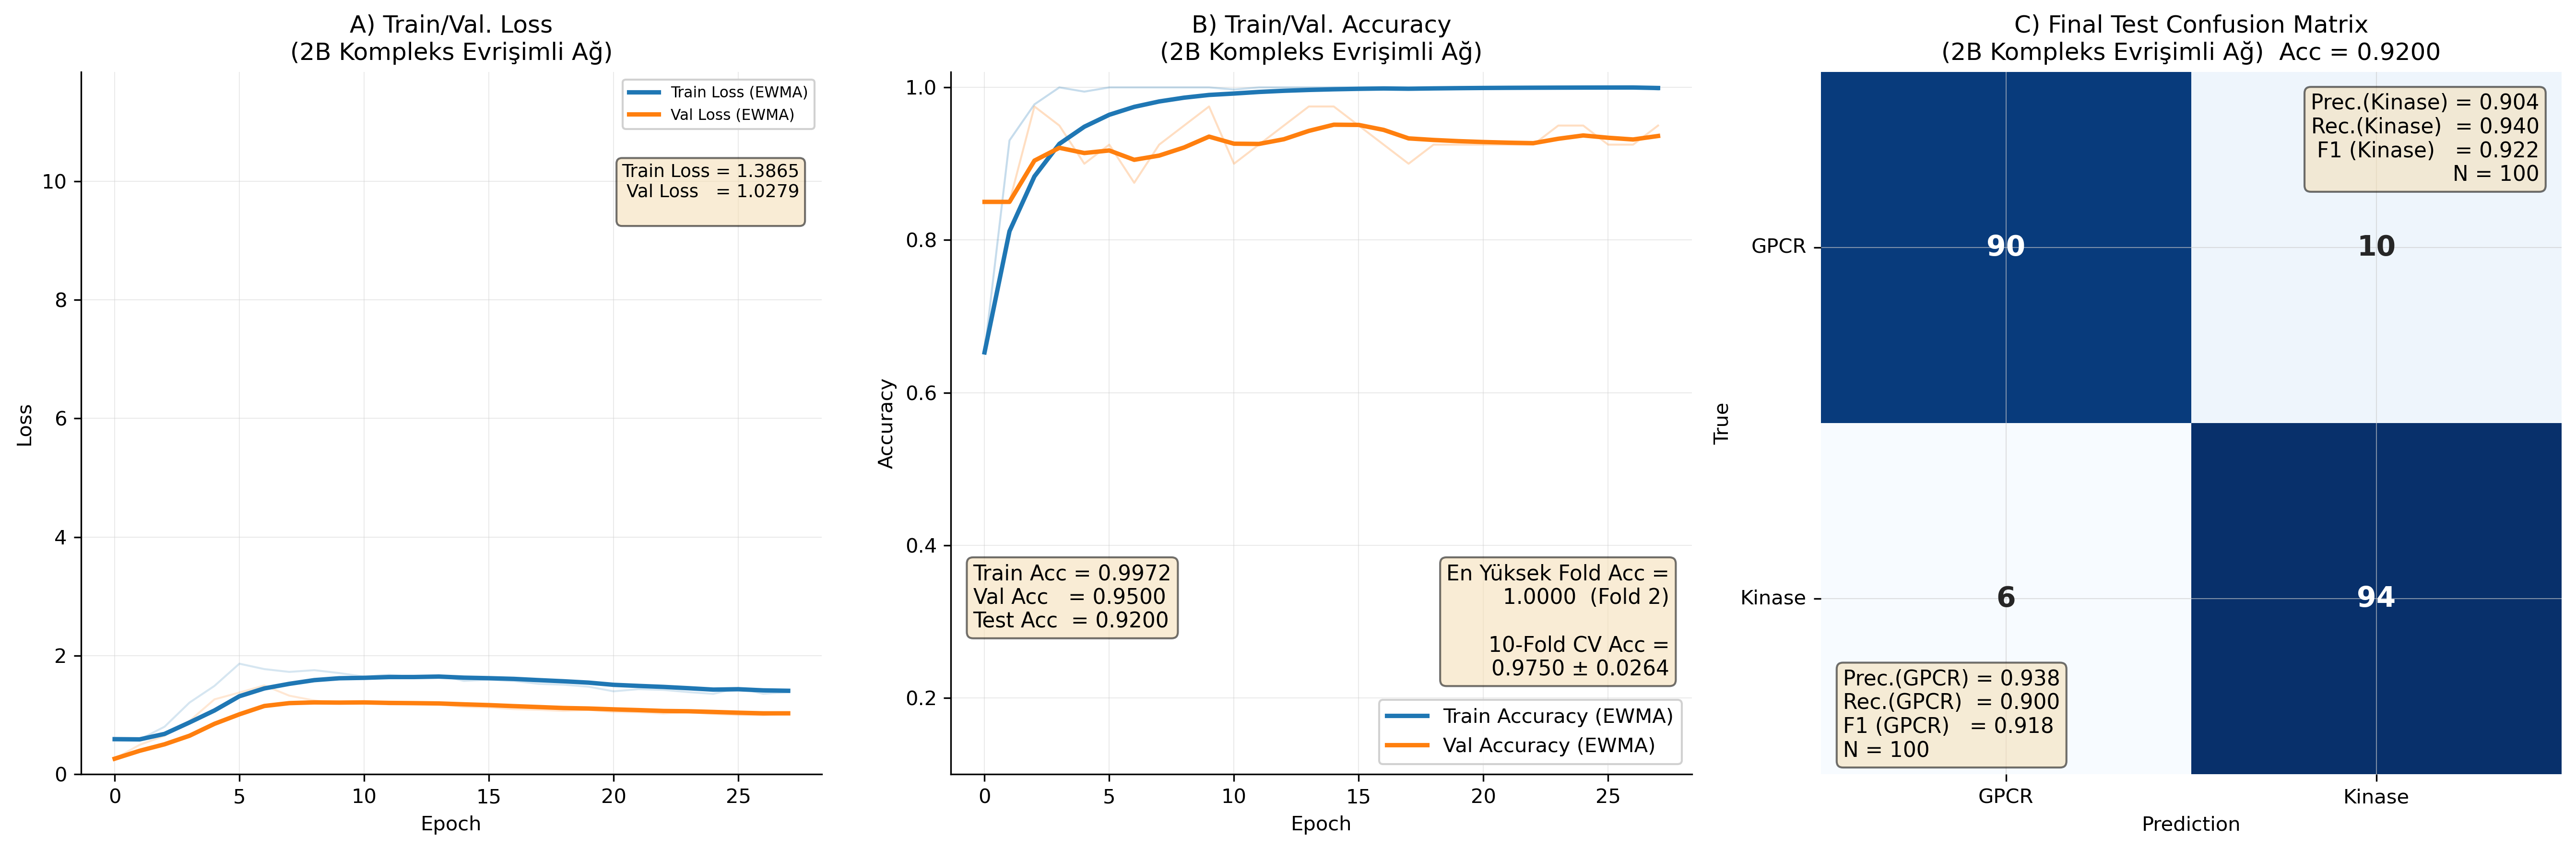

In [7]:
# =============================================================================
#   GRAFİK GÖRSELLEŞTİRME — 2B KOMPLEKS EVRİŞİMLİ YSA  (yeni npz sürümle uyumlu)
#   Panel A : Train/Val Loss (EWMA)   Panel B : Train/Val Accuracy (EWMA)
#   Panel C : Confusion Matrix + sınıf metrik kutuları
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, f1_score

ETIKETLER = ["GPCR", "Kinase"]

# -------------------------------------------------------------------------
# 1.  History anahtarları  
# -------------------------------------------------------------------------
LOSS_KEY     = "kayip"
VAL_LOSS_KEY = "val_kayip"
ACC_KEY      = "dogruluk"
VAL_ACC_KEY  = "val_dogruluk"

# -------------------------------------------------------------------------
# 2.  EWMA yumuşatma
# -------------------------------------------------------------------------
def ewma_yumusat(dizi, alpha: float = 0.25) -> np.ndarray:
    return (pd.Series(np.asarray(dizi, dtype=float))
              .ewm(alpha=alpha, adjust=True)
              .mean()
              .values)

h = final_history.history

train_loss_ham = np.asarray(h[LOSS_KEY],     dtype=float)
val_loss_ham   = np.asarray(h[VAL_LOSS_KEY], dtype=float)
train_acc_ham  = np.asarray(h[ACC_KEY],      dtype=float)
val_acc_ham    = np.asarray(h[VAL_ACC_KEY],  dtype=float)

train_loss_sm = ewma_yumusat(train_loss_ham, alpha=0.25)
val_loss_sm   = ewma_yumusat(val_loss_ham,   alpha=0.25)
train_acc_sm  = ewma_yumusat(train_acc_ham,  alpha=0.25)
val_acc_sm    = ewma_yumusat(val_acc_ham,    alpha=0.25)

# -------------------------------------------------------------------------
# 3.  Son epoch değerleri
# -------------------------------------------------------------------------
train_loss_son = float(train_loss_ham[-1])
val_loss_son   = float(val_loss_ham[-1])
train_acc_son  = float(train_acc_ham[-1])
val_acc_son    = float(val_acc_ham[-1])

# -------------------------------------------------------------------------
# 4.  Test sınıf metrikleri  (final model tahmini)
# -------------------------------------------------------------------------
prec, rec, f1, sup = precision_recall_fscore_support(
    y_test_int, y_test_pred, labels=[0, 1], average=None, zero_division=0)
macro_f1_test = f1_score(y_test_int, y_test_pred, average="macro", zero_division=0)

# -------------------------------------------------------------------------
# 5.  CV özet  (cv_df Den)
# -------------------------------------------------------------------------
cv_acc_mean = float(cv_df["acc"].mean())
cv_acc_std  = float(cv_df["acc"].std(ddof=1))
cv_f1_mean  = float(cv_df["macro_f1"].mean())
cv_f1_std   = float(cv_df["macro_f1"].std(ddof=1))

en_yuksek_fold_acc = float(cv_df["acc"].max())
en_yuksek_fold_no  = int(cv_df.loc[cv_df["acc"].idxmax(), "fold"])

# -------------------------------------------------------------------------
# 6.  Metin kutuları
# -------------------------------------------------------------------------
props = dict(boxstyle="round", facecolor="wheat", alpha=0.55)

text_loss = "\n".join((
    f"Train Loss = {train_loss_son:.4f}",
    f"Val Loss   = {val_loss_son:.4f}",
    "",
))

text_acc_1 = "\n".join((
    f"Train Acc = {train_acc_son:.4f}",
    f"Val Acc   = {val_acc_son:.4f}",
    f"Test Acc  = {test_acc:.4f}",
))

text_acc_2 = "\n".join((
    f"En Yüksek Fold Acc =",
    f"{en_yuksek_fold_acc:.4f}  (Fold {en_yuksek_fold_no})",
    "",
    f"10-Fold CV Acc =",
    f"{cv_acc_mean:.4f} ± {cv_acc_std:.4f}",
))

text_gpcr = "\n".join((
    f"Prec.(GPCR) = {prec[0]:.3f}",
    f"Rec.(GPCR)  = {rec[0]:.3f}",
    f"F1 (GPCR)   = {f1[0]:.3f}",
    f"N = {sup[0]}",
))
text_kinase = "\n".join((
    f"Prec.(Kinase) = {prec[1]:.3f}",
    f"Rec.(Kinase)  = {rec[1]:.3f}",
    f"F1 (Kinase)   = {f1[1]:.3f}",
    f"N = {sup[1]}",
))

# -------------------------------------------------------------------------
# 7.  Grafik
# -------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

C_TRAIN = "#1f77b4"
C_VAL   = "#ff7f0e"

# A) Loss
ax[0].plot(train_loss_ham, color=C_TRAIN, linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(val_loss_ham,   color=C_VAL,   linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(train_loss_sm,  color=C_TRAIN, linewidth=2.2, label="Train Loss (EWMA)")
ax[0].plot(val_loss_sm,    color=C_VAL,   linewidth=2.2, label="Val Loss (EWMA)")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss")
ax[0].grid(True, alpha=0.4)
ax[0].legend(loc="upper right", framealpha=0.9, fontsize=7.5)
ax[0].set_title("A) Train/Val. Loss\n(2B Kompleks Evrişimli Ağ)")
ymax_loss = max(np.nanmax(train_loss_ham), np.nanmax(val_loss_ham))
ax[0].set_ylim(0.0, max(0.5, ymax_loss * 6.35))
ax[0].text(0.97, 0.87, text_loss, transform=ax[0].transAxes, ha="right", va="top",
           fontsize=9.0, bbox=props)

# B) Accuracy
ax[1].plot(train_acc_ham, color=C_TRAIN, linewidth=1.0, alpha=0.25, label="_nolegend_")
ax[1].plot(val_acc_ham,   color=C_VAL,   linewidth=1.0, alpha=0.25, label="_nolegend_")
ax[1].plot(train_acc_sm,  color=C_TRAIN, linewidth=2.2, label="Train Accuracy (EWMA)")
ax[1].plot(val_acc_sm,    color=C_VAL,   linewidth=2.2, label="Val Accuracy (EWMA)")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy")
ax[1].grid(True, alpha=0.4)
ax[1].legend(loc="lower right", framealpha=0.9)
ax[1].set_title("B) Train/Val. Accuracy\n(2B Kompleks Evrişimli Ağ)")
ax[1].set_ylim(0.1, 1.02)
ax[1].text(0.03, 0.30, text_acc_1, transform=ax[1].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)
ax[1].text(0.97, 0.30, text_acc_2, transform=ax[1].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)

# C) Confusion Matrix
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[2],
            annot_kws={"size": 14, "weight": "bold"})
ax[2].set_xlabel("Prediction"); ax[2].set_ylabel("True")
ax[2].set_title(f"C) Final Test Confusion Matrix\n"
                f"(2B Kompleks Evrişimli Ağ)  Acc = {test_acc:.4f}")
ax[2].set_xticklabels([ETIKETLER[0], ETIKETLER[1]])
ax[2].set_yticklabels([ETIKETLER[0], ETIKETLER[1]], rotation=0)
ax[2].text(0.03, 0.15, text_gpcr,   transform=ax[2].transAxes, ha="left",  va="top",
           fontsize=10.5, bbox=props)
ax[2].text(0.97, 0.97, text_kinase, transform=ax[2].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)

plt.tight_layout()
plt.savefig("2d_kompleks_sonuc_grafik.png", dpi=600, bbox_inches="tight")
plt.show()


#### ADIM 3 (Reel Değerli 2B Evrişimli Sinir Ağları)
- Reel Değerli 2B Evrişimli Sinir Ağları ile 2B protein temsilleri kullanılarak protein sınıflandırılması yapılmaktadır.

In [1]:
# =============================================================================
#  2b EVRİŞİMLİ REEL-DEĞERLİ YSA (GPCR vs KINASE)  —  
#
#   GİRDİ : 2B_Temssil_kodlama/egitim.npz , test.npz
#           Kompleks ağ ile AYNI tek-kaynak ızgara; reel ağ bunu [gerçek, sanal]
#           iki kanal olarak alır (bilgi içeriği kompleks ağla AYNI yalnızca
#           işlem türü farklı )
#   NOT   : Fold bölünmesi SPLIT_SEED=42 ile (kompleks ağla ORTAK). Aynı npz,
#           aynı sıra, ön-karıştırma YOK → fold üyeliği iki ağda birebir aynı(eşleşmiş istatistik için ).
# =============================================================================

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)

import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
tf.get_logger().setLevel("ERROR")

# =============================================================================
# IMPORTS
# =============================================================================
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              precision_recall_fscore_support,
                              classification_report)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# =============================================================================
# SABİTLER
# =============================================================================
NPZ_DIR     = "2B_Temssil_kodlama"
EGITIM_NPZ  = os.path.join(NPZ_DIR, "egitim.npz")
TEST_NPZ    = os.path.join(NPZ_DIR, "test.npz")
RAPOR_XLSX  = "2d_reel_sonuc.xlsx"

CLASS_MAP   = {"gpcr": 0, "kinase": 1}
CLASS_NAMES = ["GPCR", "Kinase"]   #  0→GPCR, 1→Kinase

IMG_H = IMG_W = None    
CHANNELS      = 2       
NUM_CLASSES   = 2

N_SPLITS   = 10
EPOCHS     = 60
BATCH_SIZE = 16
LR         = 1e-4

# --- ORTAK TOHUM (kompleks ağ ile AYNI fold bölünmesi) ---
SPLIT_SEED = 42
RUN_SEED   = SPLIT_SEED     

# =============================================================================
# SEED
# =============================================================================
def set_seed(seed):
    tf.keras.utils.set_random_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(RUN_SEED)
print(f"[INFO] SPLIT_SEED / RUN_SEED = {SPLIT_SEED}")

# =============================================================================
# VERİ YÜKLEME  (npz kompleks ızgara → [gerçek, sanal] 2 kanal)
# =============================================================================
def veri_yukle_npz(yol):
    d = np.load(yol, allow_pickle=True)
    X = d["X"].astype(np.complex64)      # 
    y = d["y"].astype(int)
    return X, y

print("[INFO] Veri yükleniyor (npz)...")
X_train_c, y_train = veri_yukle_npz(EGITIM_NPZ)
X_test_c,  y_test  = veri_yukle_npz(TEST_NPZ)

# Genlik ölçekleme: faz korunur; kompleks ağ ile AYNI ölçek (aynı npz).
olcek = float(np.abs(X_train_c).max())
if olcek == 0.0:
    olcek = 1.0
X_train_c = X_train_c / olcek
X_test_c  = X_test_c  / olcek

IMG_H, IMG_W = int(X_train_c.shape[1]), int(X_train_c.shape[2])

# reel ağ girdisi: aynı ızgaranın [gerçek, sanal] iki kanalı
X_train = np.stack([X_train_c.real, X_train_c.imag], axis=-1).astype(np.float32)
X_test  = np.stack([X_test_c.real,  X_test_c.imag],  axis=-1).astype(np.float32)

print(f"Izgara : {IMG_H}x{IMG_W}x{CHANNELS} | genlik ölçeği (bölen): {olcek:.4f}")
print(f"Train  : {X_train.shape}  Test: {X_test.shape}")
print(f"  CV havuzu  : GPCR={np.sum(y_train == 0)}, Kinase={np.sum(y_train == 1)}")
print(f"  Final test : GPCR={np.sum(y_test == 0)}, Kinase={np.sum(y_test == 1)}")

# =============================================================================
# MODEL  (kompleks ağla aynı derinlik , girdi 2 kanal)
# =============================================================================
def build_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu',
               input_shape=(IMG_H, IMG_W, CHANNELS)),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        Flatten(),

        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dropout(0.3),

        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=LR, clipnorm=0.5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# =============================================================================
# CALLBACKS  --fold çökmesine karşı--
# =============================================================================
def get_callbacks():
    early_stop = EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        verbose=0
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=0
    )
    return [early_stop, reduce_lr]

# =============================================================================
# YARDIMCI: sınıf bazlı metrikler
# =============================================================================
def compute_per_class_metrics(y_true, y_pred, class_names=CLASS_NAMES):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(len(class_names))),
        average=None, zero_division=0
    )
    metrics = {}
    for i, name in enumerate(class_names):
        metrics[name] = {"precision": precision[i], "recall": recall[i], "f1": f1[i]}
    return metrics


def print_per_class_metrics(metrics, class_names=CLASS_NAMES, indent="  "):
    header = f"{indent}{'Sınıf':<10} {'Precision':>10} {'Recall':>10} {'F1':>10}"
    print(header)
    print(indent + "-" * 42)
    for name in class_names:
        m = metrics[name]
        print(f"{indent}{name:<10} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1']:>10.4f}")

# =============================================================================
# 10-FOLD CV   (fold bölünmesi SPLIT_SEED ile — kompleks ağla ORTAK)
# =============================================================================
print("\n[INFO] 10-Fold CV başlıyor...")

skf       = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SPLIT_SEED)
cv_scores = []
fold_satirlari = []      # rapor için

cv_per_class = {name: {"precision": [], "recall": [], "f1": []}
                for name in CLASS_NAMES}

for fold, (tr, vl) in enumerate(skf.split(X_train, y_train), 1):
    print(f"\n--- Fold {fold} ---")
    set_seed(RUN_SEED + fold)

    X_tr, X_vl = X_train[tr], X_train[vl]
    y_tr, y_vl = y_train[tr], y_train[vl]

    y_tr_cat = to_categorical(y_tr, NUM_CLASSES)
    y_vl_cat = to_categorical(y_vl, NUM_CLASSES)

    model = build_model()
    model.fit(X_tr, y_tr_cat,
              validation_data=(X_vl, y_vl_cat),
              epochs=EPOCHS,
              batch_size=BATCH_SIZE,
              callbacks=get_callbacks(),
              verbose=0)

    pred = np.argmax(model.predict(X_vl, verbose=0), axis=1)
    acc  = accuracy_score(y_vl, pred)
    f1   = f1_score(y_vl, pred, average='macro')

    fold_metrics = compute_per_class_metrics(y_vl, pred)
    for name in CLASS_NAMES:
        cv_per_class[name]["precision"].append(fold_metrics[name]["precision"])
        cv_per_class[name]["recall"].append(fold_metrics[name]["recall"])
        cv_per_class[name]["f1"].append(fold_metrics[name]["f1"])

    cv_scores.append((acc, f1))
    fold_satirlari.append({
        "model": "2D_Reel_CNN", "fold": fold, "acc": acc, "macro_f1": f1,
        "gpcr_f1": fold_metrics["GPCR"]["f1"], "kinase_f1": fold_metrics["Kinase"]["f1"],
    })

    print(f"  Accuracy={acc:.4f} | Macro-F1={f1:.4f}")
    print_per_class_metrics(fold_metrics)

# =============================================================================
# CV ÖZET
# =============================================================================
accs = [s[0] for s in cv_scores]
f1s  = [s[1] for s in cv_scores]
print(f"\n{'='*55}")
print("CV ÖZET (10 Fold)")
print(f"{'='*55}")
print(f"  Accuracy : {np.mean(accs):.4f} ± {np.std(accs, ddof=1):.4f}")
print(f"  Macro-F1 : {np.mean(f1s):.4f}  ± {np.std(f1s, ddof=1):.4f}")
print()

print(f"  {'Sınıf':<10} {'Metrik':<12} {'Ortalama':>10} {'Std':>10}")
print("  " + "-" * 46)
for name in CLASS_NAMES:
    for metric in ["precision", "recall", "f1"]:
        vals = cv_per_class[name][metric]
        print(f"  {name:<10} {metric:<12} {np.mean(vals):>10.4f} {np.std(vals, ddof=1):>10.4f}")
    print("  " + "- " * 23)

# =============================================================================
# FINAL MODEL   (iç doğrulama bölmesi de SPLIT_SEED ile — kompleks ağla aynı)
# =============================================================================
print("\n[INFO] Final model eğitiliyor...")

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=SPLIT_SEED)
tr_idx, vl_idx = next(sss.split(X_train, y_train))

X_tr, X_vl = X_train[tr_idx], X_train[vl_idx]
y_tr, y_vl = y_train[tr_idx], y_train[vl_idx]

y_tr_cat = to_categorical(y_tr, NUM_CLASSES)
y_vl_cat = to_categorical(y_vl, NUM_CLASSES)

set_seed(RUN_SEED)
model = build_model()
reel_final_history = model.fit(
    X_tr, y_tr_cat,
    validation_data=(X_vl, y_vl_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=1
)

# =============================================================================
# TEST
# =============================================================================
print("\n[INFO] Test değerlendirme...")

pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
acc  = accuracy_score(y_test, pred)
f1   = f1_score(y_test, pred, average='macro')
cm   = confusion_matrix(y_test, pred, labels=[0, 1])

test_metrics = compute_per_class_metrics(y_test, pred)

print(f"\n{'='*55}")
print("TEST SONUÇLARI  (2D Reel CNN)")
print(f"{'='*55}")
print("\nConfusion Matrix:")
print(cm)
print(f"\n  Test Accuracy : {acc:.4f}")
print(f"  Test Macro-F1 : {f1:.4f}")
print()
print("  Sınıf Bazlı Metrikler:")
print_per_class_metrics(test_metrics)

print("\n  --- Scikit-learn Classification Report ---")
print(classification_report(y_test, pred,
                             target_names=CLASS_NAMES,
                             digits=4,
                             zero_division=0))

# =============================================================================
# RAPOR  (acc & test acc dosyaya)   kayıt, 2d_reel_sonuc.xlsx
# =============================================================================
fold_metrikleri = pd.DataFrame(fold_satirlari)

ozet = pd.DataFrame([{
    "model":            "2D_Reel_CNN",
    "split_seed":       SPLIT_SEED,
    "izgara":           f"{IMG_H}x{IMG_W}x{CHANNELS}",
    "cv_acc_ort":       float(np.mean(accs)),
    "cv_acc_std":       float(np.std(accs, ddof=1)),
    "cv_macrof1_ort":   float(np.mean(f1s)),
    "cv_macrof1_std":   float(np.std(f1s, ddof=1)),
    "test_acc":         float(acc),
    "test_macro_f1":    float(f1),
}])

with pd.ExcelWriter(RAPOR_XLSX) as w:
    ozet.to_excel(w,            sheet_name="ozet",            index=False)
    fold_metrikleri.to_excel(w, sheet_name="fold_metrikleri", index=False)

print(f"\n[OK] Rapor kaydedildi: {RAPOR_XLSX}")
print(f"     CV acc = {np.mean(accs):.4f} ± {np.std(accs, ddof=1):.4f} | "
      f"Test acc = {acc:.4f}")



[INFO] SPLIT_SEED / RUN_SEED = 42
[INFO] Veri yükleniyor (npz)...
Izgara : 128x128x2 | genlik ölçeği (bölen): 39.9993
Train  : (400, 128, 128, 2)  Test: (200, 128, 128, 2)
  CV havuzu  : GPCR=200, Kinase=200
  Final test : GPCR=100, Kinase=100

[INFO] 10-Fold CV başlıyor...

--- Fold 1 ---
  Accuracy=0.9750 | Macro-F1=0.9750
  Sınıf       Precision     Recall         F1
  ------------------------------------------
  GPCR           0.9524     1.0000     0.9756
  Kinase         1.0000     0.9500     0.9744

--- Fold 2 ---
  Accuracy=1.0000 | Macro-F1=1.0000
  Sınıf       Precision     Recall         F1
  ------------------------------------------
  GPCR           1.0000     1.0000     1.0000
  Kinase         1.0000     1.0000     1.0000

--- Fold 3 ---
  Accuracy=0.9750 | Macro-F1=0.9750
  Sınıf       Precision     Recall         F1
  ------------------------------------------
  GPCR           1.0000     0.9500     0.9744
  Kinase         0.9524     1.0000     0.9756

--- Fold 4 ---
  

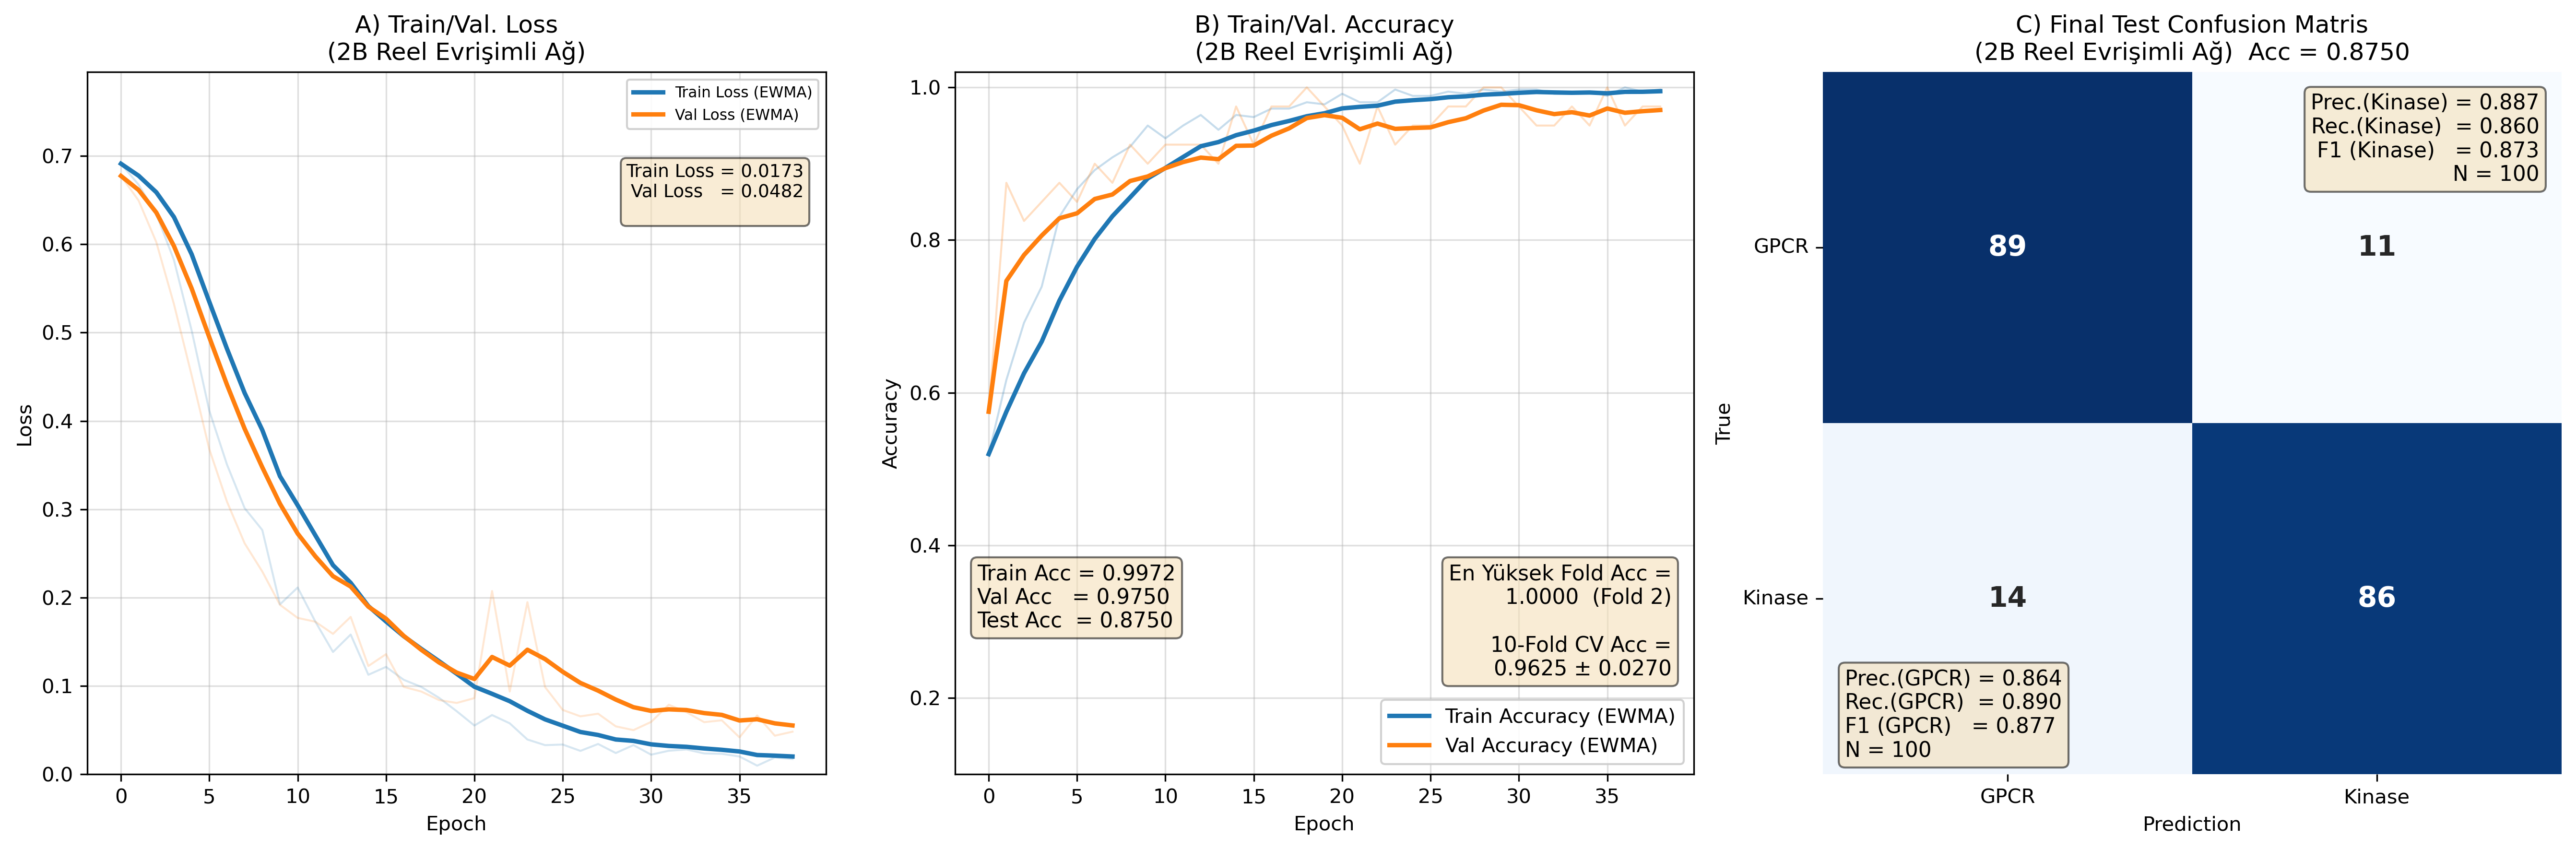

In [2]:
# =============================================================================
#   GRAFİK GÖRSELLEŞTİRME — 2B REEL EVRİŞİMLİ YSA  
#   Panel A : Train/Val Loss (EWMA)   
# Panel B : Train/Val Accuracy (EWMA)
#   Panel C : Confusion Matrix + sınıf metrik kutuları
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, f1_score

SINIF_ADLARI = ["GPCR", "Kinase"]

# -------------------------------------------------------------------------
# 1.  History anahtarları  (standart Keras)
# -------------------------------------------------------------------------
LOSS_KEY     = "loss"
VAL_LOSS_KEY = "val_loss"
ACC_KEY      = "accuracy"
VAL_ACC_KEY  = "val_accuracy"

# -------------------------------------------------------------------------
# 2.  EWMA yumuşatma
# -------------------------------------------------------------------------
def ewma_yumusat(dizi, alpha: float = 0.25) -> np.ndarray:
    return (pd.Series(np.asarray(dizi, dtype=float))
              .ewm(alpha=alpha, adjust=True)
              .mean()
              .values)

h = reel_final_history.history

train_loss_ham = np.asarray(h[LOSS_KEY],     dtype=float)
val_loss_ham   = np.asarray(h[VAL_LOSS_KEY], dtype=float)
train_acc_ham  = np.asarray(h[ACC_KEY],      dtype=float)
val_acc_ham    = np.asarray(h[VAL_ACC_KEY],  dtype=float)

train_loss_sm = ewma_yumusat(train_loss_ham, alpha=0.25)
val_loss_sm   = ewma_yumusat(val_loss_ham,   alpha=0.25)
train_acc_sm  = ewma_yumusat(train_acc_ham,  alpha=0.25)
val_acc_sm    = ewma_yumusat(val_acc_ham,    alpha=0.25)

# -------------------------------------------------------------------------
# 3.  Son epoch değerleri
# -------------------------------------------------------------------------
train_loss_son = float(train_loss_ham[-1])
val_loss_son   = float(val_loss_ham[-1])
train_acc_son  = float(train_acc_ham[-1])
val_acc_son    = float(val_acc_ham[-1])

# -------------------------------------------------------------------------
# 4.  Test sınıf metrikleri
# -------------------------------------------------------------------------
prec, rec, f1, sup = precision_recall_fscore_support(
    y_test, pred, labels=[0, 1], average=None, zero_division=0)
macro_f1_test = f1_score(y_test, pred, average="macro", zero_division=0)

# -------------------------------------------------------------------------
# 5.  CV özet  
# -------------------------------------------------------------------------
cv_accs = [s[0] for s in cv_scores]
cv_f1s  = [s[1] for s in cv_scores]

cv_acc_mean = float(np.mean(cv_accs))
cv_acc_std  = float(np.std(cv_accs, ddof=1))
cv_f1_mean  = float(np.mean(cv_f1s))
cv_f1_std   = float(np.std(cv_f1s,  ddof=1))

en_yuksek_fold_acc = float(np.max(cv_accs))
en_yuksek_fold_no  = int(np.argmax(cv_accs)) + 1

# -------------------------------------------------------------------------
# 6.  Metin kutuları
# -------------------------------------------------------------------------
props = dict(boxstyle="round", facecolor="wheat", alpha=0.55)

text_loss = "\n".join((
    f"Train Loss = {train_loss_son:.4f}",
    f"Val Loss   = {val_loss_son:.4f}",
    "",
))

text_acc_1 = "\n".join((
    f"Train Acc = {train_acc_son:.4f}",
    f"Val Acc   = {val_acc_son:.4f}",
    f"Test Acc  = {acc:.4f}",
))

text_acc_2 = "\n".join((
    f"En Yüksek Fold Acc =",
    f"{en_yuksek_fold_acc:.4f}  (Fold {en_yuksek_fold_no})",
    "",
    f"10-Fold CV Acc =",
    f"{cv_acc_mean:.4f} ± {cv_acc_std:.4f}",
))

text_gpcr = "\n".join((
    f"Prec.(GPCR) = {prec[0]:.3f}",
    f"Rec.(GPCR)  = {rec[0]:.3f}",
    f"F1 (GPCR)   = {f1[0]:.3f}",
    f"N = {sup[0]}",
))
text_kinase = "\n".join((
    f"Prec.(Kinase) = {prec[1]:.3f}",
    f"Rec.(Kinase)  = {rec[1]:.3f}",
    f"F1 (Kinase)   = {f1[1]:.3f}",
    f"N = {sup[1]}",
))

# -------------------------------------------------------------------------
# 7.  Grafik
# -------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

C_TRAIN = "#1f77b4"
C_VAL   = "#ff7f0e"

# A) Loss
ax[0].plot(train_loss_ham, color=C_TRAIN, linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(val_loss_ham,   color=C_VAL,   linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(train_loss_sm,  color=C_TRAIN, linewidth=2.2, label="Train Loss (EWMA)")
ax[0].plot(val_loss_sm,    color=C_VAL,   linewidth=2.2, label="Val Loss (EWMA)")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss")
ax[0].grid(True, alpha=0.4)
ax[0].legend(loc="upper right", framealpha=0.9, fontsize=7.5)
ax[0].set_title("A) Train/Val. Loss\n(2B Reel Evrişimli Ağ)")
ymax_loss = max(np.nanmax(train_loss_ham), np.nanmax(val_loss_ham))
ax[0].set_ylim(0.0, max(0.5, ymax_loss * 1.15))
ax[0].text(0.97, 0.87, text_loss, transform=ax[0].transAxes, ha="right", va="top",
           fontsize=9.0, bbox=props)

# B) Accuracy
ax[1].plot(train_acc_ham, color=C_TRAIN, linewidth=1.0, alpha=0.25, label="_nolegend_")
ax[1].plot(val_acc_ham,   color=C_VAL,   linewidth=1.0, alpha=0.25, label="_nolegend_")
ax[1].plot(train_acc_sm,  color=C_TRAIN, linewidth=2.2, label="Train Accuracy (EWMA)")
ax[1].plot(val_acc_sm,    color=C_VAL,   linewidth=2.2, label="Val Accuracy (EWMA)")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy")
ax[1].grid(True, alpha=0.4)
ax[1].legend(loc="lower right", framealpha=0.9)
ax[1].set_title("B) Train/Val. Accuracy\n(2B Reel Evrişimli Ağ)")
ax[1].set_ylim(0.1, 1.02)
ax[1].text(0.03, 0.30, text_acc_1, transform=ax[1].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)
ax[1].text(0.97, 0.30, text_acc_2, transform=ax[1].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)

# C) Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[2],
            annot_kws={"size": 14, "weight": "bold"})
ax[2].set_xlabel("Prediction"); ax[2].set_ylabel("True")
ax[2].set_title(f"C) Final Test Confusion Matris\n"
                f"(2B Reel Evrişimli Ağ)  Acc = {acc:.4f}")
ax[2].set_xticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]])
ax[2].set_yticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]], rotation=0)
ax[2].text(0.03, 0.15, text_gpcr,   transform=ax[2].transAxes, ha="left",  va="top",
           fontsize=10.5, bbox=props)
ax[2].text(0.97, 0.97, text_kinase, transform=ax[2].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)

plt.tight_layout()
plt.savefig("2d_reel_sonuc_grafik.png", dpi=600, bbox_inches="tight")
plt.show()

#### ADIM 4 (Destek Vektör Makineleri)
- Destek Vektör Makineleri makine öğrenme yöntemiyle 2B protein temsilleri kullanılarak protein sınıflandırılması yapılmaktadır.

In [1]:
# =============================================================================
#  SVM (GPCR ve KINASE)
#
#   Fold bölünmesi SPLIT_SEED=42 (diğer modellerle ORTAK). Ön-karıştırma YOK.
#   10-Fold CV: Accuracy, Macro-F1, GPCR-F1 ve Kinase-F1
# =============================================================================

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import warnings; warnings.filterwarnings("ignore")
import logging; logging.getLogger().setLevel(logging.ERROR)

import random
import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              precision_recall_fscore_support, classification_report)

# =============================================================================
# SABİTLER
# =============================================================================
NPZ_DIR     = "2B_Temssil_kodlama"
EGITIM_NPZ  = os.path.join(NPZ_DIR, "egitim.npz")
TEST_NPZ    = os.path.join(NPZ_DIR, "test.npz")
RAPOR_XLSX  = "svm_sonuc.xlsx"

CLASS_NAMES = ["GPCR", "Kinase"]
N_SPLITS    = 10
PCA_BILESEN = 100        # SVM oncesi boyut indirgeme

SPLIT_SEED  = 42
RUN_SEED    = SPLIT_SEED
np.random.seed(RUN_SEED)
random.seed(RUN_SEED)

print(f"[INFO] SPLIT_SEED / RUN_SEED = {SPLIT_SEED}")

# =============================================================================
# VERİ  (npz kompleks ızgara -> [gerçek ve sanal] düz.)
# =============================================================================
def veri_yukle_npz(yol):
    d = np.load(yol, allow_pickle=True)
    return d["X"].astype(np.complex64), d["y"].astype(int)


def duzlestir(Xc):
    N = Xc.shape[0]
    return np.concatenate([
        Xc.real.reshape(N, -1),
        Xc.imag.reshape(N, -1)
    ], axis=1).astype(np.float32)


print("[INFO] Veri yükleniyor (npz)...")

X_train_c, y_train = veri_yukle_npz(EGITIM_NPZ)
X_test_c,  y_test  = veri_yukle_npz(TEST_NPZ)

IMG_H, IMG_W = int(X_train_c.shape[1]), int(X_train_c.shape[2])

X_train = duzlestir(X_train_c)
X_test  = duzlestir(X_test_c)

print(f"Girdi  : öznitelik boyutu = {X_train.shape[1]} (= 2·{IMG_H}·{IMG_W})")
print(f"Train  : {X_train.shape}  Test: {X_test.shape}")

print(f"  CV havuzu  : GPCR={np.sum(y_train == 0)}, "
      f"Kinase={np.sum(y_train == 1)}")

print(f"  Final test : GPCR={np.sum(y_test == 0)}, "
      f"Kinase={np.sum(y_test == 1)}")


n_comp = int(min(
    PCA_BILESEN,
    X_train.shape[0] - 2,
    X_train.shape[1]
))


def yeni_pipe():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(
            n_components=n_comp,
            svd_solver="randomized",
            random_state=SPLIT_SEED
        )),
        ("svc", SVC(
            class_weight="balanced",
            random_state=RUN_SEED
        )),
    ])


# =============================================================================
# HİPERPARAMETRE ARAMA
# (Pipeline, lineer + RBF; balanced_accuracy; n_jobs=1)
# =============================================================================
print(
    f"\n[INFO] GridSearchCV "
    f"(Pipeline: Scaler->PCA({n_comp})->SVC, sızıntısız)..."
)

param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10]
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [1, 10, 100],
        "svc__gamma": ["scale", 0.01, 0.001]
    },
]

ic_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SPLIT_SEED
)

grid = GridSearchCV(
    yeni_pipe(),
    param_grid,
    cv=ic_cv,
    scoring="balanced_accuracy",
    n_jobs=1,
    verbose=0
)

grid.fit(X_train, y_train)

en_iyi = grid.best_params_

print(f"En iyi parametreler → {en_iyi}")
print(f"GridSearchCV (dengeli doğruluk): {grid.best_score_:.4f}")


# =============================================================================
# YARDIMCI
# =============================================================================
def compute_per_class_metrics(y_true, y_pred, class_names=CLASS_NAMES):

    p, r, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(class_names))),
        average=None,
        zero_division=0
    )

    return {
        n: {
            "precision": p[i],
            "recall": r[i],
            "f1": f1[i]
        }
        for i, n in enumerate(class_names)
    }


def print_per_class_metrics(m, class_names=CLASS_NAMES, indent="  "):

    print(
        f"{indent}{'Sınıf':<10} "
        f"{'Precision':>10} "
        f"{'Recall':>10} "
        f"{'F1':>10}"
    )

    print(indent + "-" * 42)

    for n in class_names:
        print(
            f"{indent}{n:<10} "
            f"{m[n]['precision']:>10.4f} "
            f"{m[n]['recall']:>10.4f} "
            f"{m[n]['f1']:>10.4f}"
        )


# =============================================================================
# 10-FOLD CV  (kat-başına fit)
# =============================================================================
print("\n[INFO] 10-Fold CV (kat-başına Scaler+PCA+SVC)...")

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SPLIT_SEED
)

cv_scores = []
fold_satirlari = []

cv_per_class = {
    n: {
        "precision": [],
        "recall": [],
        "f1": []
    }
    for n in CLASS_NAMES
}


for fold, (tr, vl) in enumerate(skf.split(X_train, y_train), 1):

    pipe = clone(grid.best_estimator_)

    pipe.fit(
        X_train[tr],
        y_train[tr]
    )

    pred = pipe.predict(X_train[vl])

    # -------------------------------------------------------------------------
    # Genel metrikler
    # -------------------------------------------------------------------------
    acc = accuracy_score(
        y_train[vl],
        pred
    )

    f1 = f1_score(
        y_train[vl],
        pred,
        average="macro"
    )

    # -------------------------------------------------------------------------
    # Sınıf bazlı metrikler
    # -------------------------------------------------------------------------
    fm = compute_per_class_metrics(
        y_train[vl],
        pred
    )

    for n in CLASS_NAMES:
        for k in ("precision", "recall", "f1"):
            cv_per_class[n][k].append(
                fm[n][k]
            )

    # -------------------------------------------------------------------------
    # Fold sonuçları
    # -------------------------------------------------------------------------
    cv_scores.append(
        (acc, f1)
    )

    fold_satirlari.append({
        "model": "SVM",
        "fold": fold,
        "acc": acc,
        "macro_f1": f1,

        # SINIF BAZLI F1
        "gpcr_f1": fm["GPCR"]["f1"],
        "kinase_f1": fm["Kinase"]["f1"]
    })

    print(
        f"  Fold {fold}: "
        f"acc={acc:.4f} | "
        f"macro-F1={f1:.4f} | "
        f"GPCR-F1={fm['GPCR']['f1']:.4f} | "
        f"Kinase-F1={fm['Kinase']['f1']:.4f}"
    )


# =============================================================================
# 10-FOLD CV ÖZETLERİ
# =============================================================================
accs = [
    s[0]
    for s in cv_scores
]

f1s = [
    s[1]
    for s in cv_scores
]

# -------------------------------------------------------------------------
# GPCR ve Kinase F1 değerleri
# -------------------------------------------------------------------------
gpcr_f1s = cv_per_class["GPCR"]["f1"]

kinase_f1s = cv_per_class["Kinase"]["f1"]


print(
    f"\n{'='*65}\n"
    f"CV ÖZET (10 Fold) — SVM\n"
    f"{'='*65}"
)

print(
    f"  Accuracy   : "
    f"{np.mean(accs):.4f} ± "
    f"{np.std(accs, ddof=1):.4f}"
)

print(
    f"  Macro-F1   : "
    f"{np.mean(f1s):.4f} ± "
    f"{np.std(f1s, ddof=1):.4f}"
)

print(
    f"  GPCR F1    : "
    f"{np.mean(gpcr_f1s):.4f} ± "
    f"{np.std(gpcr_f1s, ddof=1):.4f}"
)

print(
    f"  Kinase F1  : "
    f"{np.mean(kinase_f1s):.4f} ± "
    f"{np.std(kinase_f1s, ddof=1):.4f}"
)


# =============================================================================
# FINAL MODEL + TEST
# =============================================================================
final_svm = grid.best_estimator_

X_test_sc = X_test

print("\n[INFO] Test değerlendirme...")

pred_test = final_svm.predict(X_test)

acc = accuracy_score(
    y_test,
    pred_test
)

f1 = f1_score(
    y_test,
    pred_test,
    average="macro"
)

cm = confusion_matrix(
    y_test,
    pred_test,
    labels=[0, 1]
)

test_metrics = compute_per_class_metrics(
    y_test,
    pred_test
)


print(
    f"\n{'='*55}\n"
    f"TEST SONUÇLARI — SVM\n"
    f"{'='*55}"
)

print("\nConfusion Matrix:")
print(cm)

print(
    f"\n  Test Accuracy : {acc:.4f}"
)

print(
    f"  Test Macro-F1 : {f1:.4f}"
)

print(
    f"  Test GPCR F1  : "
    f"{test_metrics['GPCR']['f1']:.4f}"
)

print(
    f"  Test Kinase F1: "
    f"{test_metrics['Kinase']['f1']:.4f}\n"
)

print("  Sınıf Bazlı Metrikler:")
print_per_class_metrics(test_metrics)

print("\n  --- Scikit-learn Classification Report ---")

print(
    classification_report(
        y_test,
        pred_test,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# =============================================================================
# RAPOR
# =============================================================================
fold_metrikleri = pd.DataFrame(
    fold_satirlari
)


# =============================================================================
# ÖZET RAPOR
# =============================================================================
ozet = pd.DataFrame([{

    "model": "SVM",

    "split_seed": SPLIT_SEED,

    "izgara": f"{IMG_H}x{IMG_W}x2(PCA{n_comp})",

    # -------------------------------------------------------------------------
    # CV ACC
    # -------------------------------------------------------------------------
    "cv_acc_ort":
        float(np.mean(accs)),

    "cv_acc_std":
        float(np.std(accs, ddof=1)),

    # -------------------------------------------------------------------------
    # CV MACRO F1
    # -------------------------------------------------------------------------
    "cv_macrof1_ort":
        float(np.mean(f1s)),

    "cv_macrof1_std":
        float(np.std(f1s, ddof=1)),

    # -------------------------------------------------------------------------
    # CV GPCR F1
    # -------------------------------------------------------------------------
    "cv_gpcr_f1_ort":
        float(np.mean(gpcr_f1s)),

    "cv_gpcr_f1_std":
        float(np.std(gpcr_f1s, ddof=1)),

    # -------------------------------------------------------------------------
    # CV KINASE F1
    # -------------------------------------------------------------------------
    "cv_kinase_f1_ort":
        float(np.mean(kinase_f1s)),

    "cv_kinase_f1_std":
        float(np.std(kinase_f1s, ddof=1)),

    # -------------------------------------------------------------------------
    # TEST
    # -------------------------------------------------------------------------
    "test_acc":
        float(acc),

    "test_macro_f1":
        float(f1),

    "test_gpcr_f1":
        float(test_metrics["GPCR"]["f1"]),

    "test_kinase_f1":
        float(test_metrics["Kinase"]["f1"]),

    # -------------------------------------------------------------------------
    # EN İYİ PARAMETRE
    # -------------------------------------------------------------------------
    "en_iyi_parametre":
        str(en_iyi),

}])


# =============================================================================
# EXCEL'E KAYDET
# =============================================================================
with pd.ExcelWriter(RAPOR_XLSX) as w:

    ozet.to_excel(
        w,
        sheet_name="ozet",
        index=False
    )

    fold_metrikleri.to_excel(
        w,
        sheet_name="fold_metrikleri",
        index=False
    )


# =============================================================================
# SONUÇ
# =============================================================================
print(
    f"\n[OK] Rapor kaydedildi: {RAPOR_XLSX}"
)

print(
    f"     CV acc = "
    f"{np.mean(accs):.4f} ± "
    f"{np.std(accs, ddof=1):.4f}"
    f" | CV Macro-F1 = "
    f"{np.mean(f1s):.4f} ± "
    f"{np.std(f1s, ddof=1):.4f}"
)

print(
    f"     CV GPCR-F1 = "
    f"{np.mean(gpcr_f1s):.4f} ± "
    f"{np.std(gpcr_f1s, ddof=1):.4f}"
    f" | CV Kinase-F1 = "
    f"{np.mean(kinase_f1s):.4f} ± "
    f"{np.std(kinase_f1s, ddof=1):.4f}"
)

print(
    f"     Test acc = {acc:.4f}"
    f" | Test Macro-F1 = {f1:.4f}"
)

print(
    f"     Test GPCR-F1 = "
    f"{test_metrics['GPCR']['f1']:.4f}"
    f" | Test Kinase-F1 = "
    f"{test_metrics['Kinase']['f1']:.4f}"
)

[INFO] SPLIT_SEED / RUN_SEED = 42
[INFO] Veri yükleniyor (npz)...
Girdi  : öznitelik boyutu = 32768 (= 2·128·128)
Train  : (400, 32768)  Test: (200, 32768)
  CV havuzu  : GPCR=200, Kinase=200
  Final test : GPCR=100, Kinase=100

[INFO] GridSearchCV (Pipeline: Scaler->PCA(100)->SVC, sızıntısız)...
En iyi parametreler → {'svc__C': 0.01, 'svc__kernel': 'linear'}
GridSearchCV (dengeli doğruluk): 0.9400

[INFO] 10-Fold CV (kat-başına Scaler+PCA+SVC)...
  Fold 1: acc=0.9500 | macro-F1=0.9499 | GPCR-F1=0.9474 | Kinase-F1=0.9524
  Fold 2: acc=0.9750 | macro-F1=0.9750 | GPCR-F1=0.9756 | Kinase-F1=0.9744
  Fold 3: acc=0.9750 | macro-F1=0.9750 | GPCR-F1=0.9744 | Kinase-F1=0.9756
  Fold 4: acc=0.9500 | macro-F1=0.9500 | GPCR-F1=0.9500 | Kinase-F1=0.9500
  Fold 5: acc=0.9750 | macro-F1=0.9750 | GPCR-F1=0.9744 | Kinase-F1=0.9756
  Fold 6: acc=0.9500 | macro-F1=0.9499 | GPCR-F1=0.9474 | Kinase-F1=0.9524
  Fold 7: acc=1.0000 | macro-F1=1.0000 | GPCR-F1=1.0000 | Kinase-F1=1.0000
  Fold 8: acc=0.9250 | 

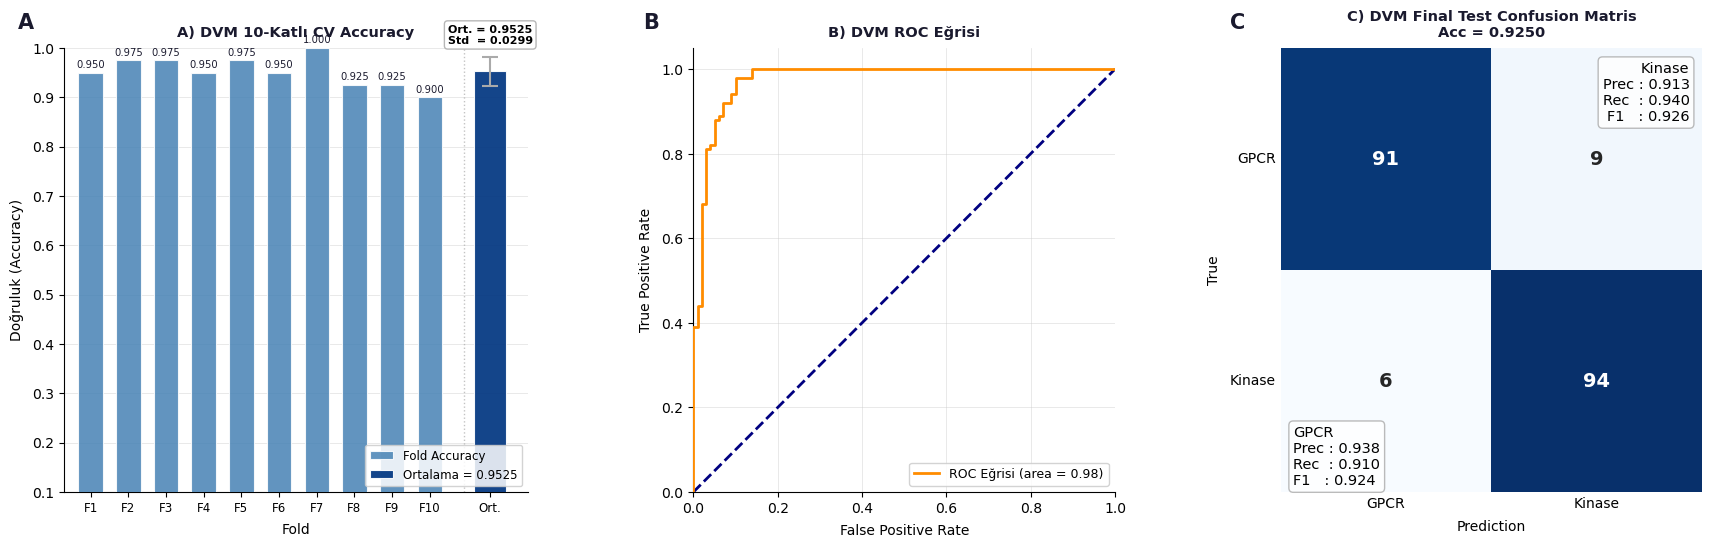

In [2]:
# =============================================================================
# DVM SONUÇ GÖRSELLEŞTİRME  ( npz İle uyumlu)

#   Panel A : 10-Katlı CV Accuracy + Ort. Acc. çubuk dağılımı
#   Panel B : ROC Eğrisi
#   Panel C : Final Test Karışıklık Matrisi

# =============================================================================

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import roc_curve, auc

matplotlib.rcParams.update({
    "font.family"       : "DejaVu Sans",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.color"        : "#CCCCCC",
    "grid.linewidth"    : 0.5,
    "grid.alpha"        : 0.6,
})

fig = plt.figure(figsize=(18, 6), facecolor="white")
fig.subplots_adjust(left=0.06, right=0.97, top=0.88, bottom=0.14, wspace=0.38)
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1.1, 1, 1])

ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])
ax_c = fig.add_subplot(gs[2])

PANEL_LABEL = dict(fontsize=15, fontweight="bold", color="#1A1A2E", ha="left", va="top")

# =============================================================================
# PANEL A — 10-Katlı CV Accuracy Çubuk Dağılımı
# =============================================================================
fold_accs = [s[0] for s in cv_scores]
n_folds  = len(fold_accs)
mean_acc = np.mean(fold_accs)
std_acc  = np.std(fold_accs, ddof=1)

fold_x = np.arange(1, n_folds + 1)
mean_x = n_folds + 1.6
C_MEAN_BAR = "#003580"

ax_a.bar(fold_x, fold_accs, color="steelblue", width=0.65, edgecolor="white",
         linewidth=0.8, zorder=3, alpha=0.85, label="Fold Accuracy")
ax_a.bar(mean_x, mean_acc, color=C_MEAN_BAR, width=0.85, edgecolor="white",
         linewidth=0.8, zorder=3, alpha=0.92, label=f"Ortalama = {mean_acc:.4f}")
ax_a.errorbar(mean_x, mean_acc, yerr=std_acc, fmt="none", color="#AAAAAA",
              capsize=6, capthick=1.5, linewidth=1.5, zorder=5)

for xi, val in zip(fold_x, fold_accs):
    ax_a.text(xi, val + 0.006, f"{val:.3f}", ha="center", va="bottom",
              fontsize=7.2, color="#1A1A2E")

props_a = dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="#AAAAAA")
ax_a.text(mean_x, mean_acc + std_acc + 0.022,
          f"Ort. = {mean_acc:.4f}\nStd  = {std_acc:.4f}",
          ha="center", va="bottom", fontsize=8, color="black",
          fontweight="semibold", bbox=props_a, zorder=6)

ax_a.axvline(n_folds + 0.9, color="#AAAAAA", linewidth=1.0, linestyle=":",
             alpha=0.7, zorder=2)

all_x = list(fold_x) + [mean_x]
tick_lbls = [f"F{i}" for i in range(1, n_folds + 1)] + ["Ort."]
ax_a.set_xticks(all_x)
ax_a.set_xticklabels(tick_lbls, fontsize=8.5)
ax_a.set_xlabel("Fold", fontsize=10, labelpad=6)
ax_a.set_ylabel("Doğruluk (Accuracy)", fontsize=10, labelpad=6)
ax_a.set_ylim(0.10, 1.00)
ax_a.set_xlim(0.3, n_folds + 2.6)
ax_a.legend(fontsize=8.5, loc="lower right", framealpha=0.85)
ax_a.grid(axis="x", alpha=0)
ax_a.text(-0.10, 1.08, "A", transform=ax_a.transAxes, **PANEL_LABEL)
ax_a.set_title("A) DVM 10-Katlı CV Accuracy",
               fontsize=10.5, fontweight="semibold", pad=8, color="#1A1A2E")

# =============================================================================
# PANEL B — ROC Eğrisi
# =============================================================================
scores_test = final_svm.decision_function(X_test_sc)
fpr, tpr, _ = roc_curve(y_test, scores_test, pos_label=1)
roc_auc = auc(fpr, tpr)

ax_b.plot(fpr, tpr, color="darkorange", lw=2,
          label=f"ROC Eğrisi (area = {roc_auc:.2f})", zorder=4)
ax_b.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", zorder=3)
ax_b.set_xlim([0.0, 1.0]); ax_b.set_ylim([0.0, 1.05])
ax_b.set_xlabel("False Positive Rate", fontsize=10, labelpad=6)
ax_b.set_ylabel("True Positive Rate", fontsize=10, labelpad=6)
ax_b.legend(loc="lower right", fontsize=9, framealpha=0.85)
ax_b.text(-0.12, 1.08, "B", transform=ax_b.transAxes, **PANEL_LABEL)
ax_b.set_title("B) DVM ROC Eğrisi",
               fontsize=10.5, fontweight="semibold", pad=8, color="#1A1A2E")

# =============================================================================
# PANEL C — Karışıklık Matrisi
# =============================================================================
props = dict(boxstyle="round", facecolor="white", alpha=0.80, edgecolor="#AAAAAA")
m_gpcr, m_kinase = test_metrics["GPCR"], test_metrics["Kinase"]
text_gpcr = (f"GPCR\nPrec : {m_gpcr['precision']:.3f}\n"
             f"Rec  : {m_gpcr['recall']:.3f}\nF1   : {m_gpcr['f1']:.3f}")
text_kinase = (f"Kinase\nPrec : {m_kinase['precision']:.3f}\n"
               f"Rec  : {m_kinase['recall']:.3f}\nF1   : {m_kinase['f1']:.3f}")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax_c,
            linewidths=0, annot_kws={"size": 14, "weight": "bold"})
ax_c.grid(False)
for _, spine in ax_c.spines.items():
    spine.set_visible(False)
ax_c.set_xlabel("Prediction", fontsize=10, labelpad=6)
ax_c.set_ylabel("True", fontsize=10, labelpad=6)
ax_c.set_xticklabels(CLASS_NAMES, fontsize=10)
ax_c.set_yticklabels(CLASS_NAMES, fontsize=10, rotation=0)
ax_c.tick_params(length=0)
ax_c.set_title(f"C) DVM Final Test Confusion Matris\nAcc = {acc:.4f}",
               fontsize=10.5, fontweight="semibold", pad=8, color="#1A1A2E")
ax_c.text(0.03, 0.15, text_gpcr, transform=ax_c.transAxes, ha="left", va="top",
          fontsize=10.5, bbox=props)
ax_c.text(0.97, 0.97, text_kinase, transform=ax_c.transAxes, ha="right", va="top",
          fontsize=10.5, bbox=props)
ax_c.text(-0.12, 1.08, "C", transform=ax_c.transAxes, **PANEL_LABEL)

fig.savefig("svm_sonuc_grafik.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

#### ADIM 5 (Rastgele Orman)
- Rastgele Orman makine öğrenme yöntemiyle  2B kompleks temsiller kullanılarak protein sınıflandırılması yapılmaktadır.

In [10]:
# =============================================================================
#  RANDOM FOREST (GPCR vs KINASE)  
#
#   GİRDİ : gorsel_kodlama_ciktilari/egitim.npz , test.npz
#           CNN'lerle AYNI tek-kaynak kompleks ızgara; RF girdisi olarak bu
#           ızgaranın [gerçek, sanal] kısmı düzleştirilir (reel CNN ile AYNI
#           bilgi; faz dahil). Böylece 4 model TEK kaynaktan beslenir.
#   NOT   : Fold bölünmesi SPLIT_SEED=42 ile (CNN'lerle ORTAK). Aynı npz, aynı
#           sıra, ön-karıştırma YOK → fold üyeliği 4 modelde birebir aynı.
# =============================================================================

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import warnings; warnings.filterwarnings("ignore")
import logging; logging.getLogger().setLevel(logging.ERROR)

import random
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              precision_recall_fscore_support,
                              classification_report)

# =============================================================================
# SABİTLER
# =============================================================================
NPZ_DIR     = "2B_Temssil_kodlama"
EGITIM_NPZ  = os.path.join(NPZ_DIR, "egitim.npz")
TEST_NPZ    = os.path.join(NPZ_DIR, "test.npz")
RAPOR_XLSX  = "rf_sonuc.xlsx"

CLASS_NAMES = ["GPCR", "Kinase"]   # indeks 0→GPCR, 1→Kinase
N_SPLITS    = 10

# --- ORTAK TOHUM (2B EVRİŞİMLİ AĞLAR İLE AYNI fold bölünmesi) ---
SPLIT_SEED  = 42
RUN_SEED    = SPLIT_SEED            
np.random.seed(RUN_SEED); random.seed(RUN_SEED)
print(f"[INFO] SPLIT_SEED / RUN_SEED = {SPLIT_SEED}")

# =============================================================================
# VERİ YÜKLEME  (npz kompleks ızgara → [gerçek, sanal] düzleştirilmiş)
# =============================================================================
def veri_yukle_npz(yol):
    d = np.load(yol, allow_pickle=True)
    X = d["X"].astype(np.complex64)      # 
    y = d["y"].astype(int)
    return X, y

def duzlestir(Xc):
    """(N,H,W) kompleks -> (N, 2*H*W) reel: [gerçek düz | sanal düz]."""
    N = Xc.shape[0]
    return np.concatenate([Xc.real.reshape(N, -1),
                           Xc.imag.reshape(N, -1)], axis=1).astype(np.float32)

print("[INFO] Veri yükleniyor (npz)...")
X_train_c, y_train = veri_yukle_npz(EGITIM_NPZ)
X_test_c,  y_test  = veri_yukle_npz(TEST_NPZ)

# Genlik ölçekleme: (faz korunur, CNN'lerle AYNI ölçek (aynı npz).)
olcek = float(np.abs(X_train_c).max())
if olcek == 0.0:
    olcek = 1.0
X_train_c = X_train_c / olcek
X_test_c  = X_test_c  / olcek

IMG_H, IMG_W = int(X_train_c.shape[1]), int(X_train_c.shape[2])

X_train = duzlestir(X_train_c)       
X_test  = duzlestir(X_test_c)

print(f"Girdi  : [gerçek|sanal] düz -> öznitelik boyutu = {X_train.shape[1]} (= 2·{IMG_H}·{IMG_W})")
print(f"Train  : {X_train.shape}  Test: {X_test.shape}")
print(f"  CV havuzu  : GPCR={np.sum(y_train == 0)}, Kinase={np.sum(y_train == 1)}")
print(f"  Final test : GPCR={np.sum(y_test == 0)}, Kinase={np.sum(y_test == 1)}")

# =============================================================================
# HİPERPARAMETRE ARAMA  (GridSearchCV, iç CV = 5-fold, SPLIT_SEED ile)
# =============================================================================
print("\n[INFO] GridSearchCV ile hiperparametre aranıyor...")

param_grid = {
    "n_estimators"     : [100, 200, 300],
    "max_depth"        : [None, 10, 20],
    "min_samples_split": [2, 5]
}

ic_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SPLIT_SEED)
grid = GridSearchCV(
    RandomForestClassifier(random_state=RUN_SEED, n_jobs=-1),
    param_grid,
    cv=ic_cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=0
)
grid.fit(X_train, y_train)

best_n   = grid.best_params_["n_estimators"]
best_d   = grid.best_params_["max_depth"]
best_mss = grid.best_params_["min_samples_split"]

print(f"En iyi parametreler → n_estimators={best_n}, "
      f"max_depth={best_d}, min_samples_split={best_mss}")
print(f"GridSearchCV (iç-CV) doğruluğu: {grid.best_score_:.4f}")

# =============================================================================
# YARDIMCI: sınıf bazlı metrikler
# =============================================================================
def compute_per_class_metrics(y_true, y_pred, class_names=CLASS_NAMES):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(len(class_names))),
        average=None, zero_division=0)
    return {name: {"precision": precision[i], "recall": recall[i], "f1": f1[i]}
            for i, name in enumerate(class_names)}


def print_per_class_metrics(metrics, class_names=CLASS_NAMES, indent="  "):
    print(f"{indent}{'Sınıf':<10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print(indent + "-" * 42)
    for name in class_names:
        m = metrics[name]
        print(f"{indent}{name:<10} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1']:>10.4f}")

# =============================================================================
# 10-FOLD CV   (fold bölünmesi SPLIT_SEED ile — 2b kompleks ve reel evrişimli ağlar ile ORTAK)
# =============================================================================
print("\n[INFO] 10-Fold CV başlıyor...")

skf       = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SPLIT_SEED)
cv_scores = []
fold_satirlari = []     # rapor için
cv_per_class = {name: {"precision": [], "recall": [], "f1": []}
                for name in CLASS_NAMES}

for fold, (tr, vl) in enumerate(skf.split(X_train, y_train), 1):
    print(f"\n--- Fold {fold} ---")

    X_tr, X_vl = X_train[tr], X_train[vl]
    y_tr, y_vl = y_train[tr], y_train[vl]

    rf = RandomForestClassifier(
        n_estimators=best_n, max_depth=best_d,
        min_samples_split=best_mss, random_state=RUN_SEED, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    pred = rf.predict(X_vl)

    acc = accuracy_score(y_vl, pred)
    f1  = f1_score(y_vl, pred, average="macro")

    fold_metrics = compute_per_class_metrics(y_vl, pred)
    for name in CLASS_NAMES:
        cv_per_class[name]["precision"].append(fold_metrics[name]["precision"])
        cv_per_class[name]["recall"].append(fold_metrics[name]["recall"])
        cv_per_class[name]["f1"].append(fold_metrics[name]["f1"])

    cv_scores.append((acc, f1))
    fold_satirlari.append({
        "model": "RandomForest", "fold": fold, "acc": acc, "macro_f1": f1,
        "gpcr_f1": fold_metrics["GPCR"]["f1"], "kinase_f1": fold_metrics["Kinase"]["f1"],
    })

    print(f"  Accuracy={acc:.4f} | Macro-F1={f1:.4f}")
    print_per_class_metrics(fold_metrics)

# =============================================================================
# CV ÖZET
# =============================================================================
accs = [s[0] for s in cv_scores]
f1s  = [s[1] for s in cv_scores]
print(f"\n{'='*55}")
print("CV ÖZET (10 Fold) — Random Forest")
print(f"{'='*55}")
print(f"  Accuracy : {np.mean(accs):.4f} ± {np.std(accs, ddof=1):.4f}")
print(f"  Macro-F1 : {np.mean(f1s):.4f}  ± {np.std(f1s, ddof=1):.4f}")
print()

print(f"  {'Sınıf':<10} {'Metrik':<12} {'Ortalama':>10} {'Std':>10}")
print("  " + "-" * 46)
for name in CLASS_NAMES:
    for metric in ["precision", "recall", "f1"]:
        vals = cv_per_class[name][metric]
        print(f"  {name:<10} {metric:<12} {np.mean(vals):>10.4f} {np.std(vals, ddof=1):>10.4f}")
    print("  " + "- " * 23)

# =============================================================================
# FINAL MODEL  (tüm train verisi ile)
# =============================================================================
print("\n[INFO] Final model eğitiliyor (tüm train)...")
final_rf = RandomForestClassifier(
    n_estimators=best_n, max_depth=best_d,
    min_samples_split=best_mss, random_state=RUN_SEED, n_jobs=-1)
final_rf.fit(X_train, y_train)

# =============================================================================
# TEST
# =============================================================================
print("\n[INFO] Test değerlendirme...")
pred_test = final_rf.predict(X_test)

acc = accuracy_score(y_test, pred_test)
f1  = f1_score(y_test, pred_test, average="macro")
cm  = confusion_matrix(y_test, pred_test, labels=[0, 1])
test_metrics = compute_per_class_metrics(y_test, pred_test)

print(f"\n{'='*55}")
print("TEST SONUÇLARI — Random Forest")
print(f"{'='*55}")
print("\nConfusion Matrix:")
print(cm)
print(f"\n  Test Accuracy : {acc:.4f}")
print(f"  Test Macro-F1 : {f1:.4f}")
print()
print("  Sınıf Bazlı Metrikler:")
print_per_class_metrics(test_metrics)

print("\n  --- Scikit-learn Classification Report ---")
print(classification_report(y_test, pred_test,
                             target_names=CLASS_NAMES, digits=4, zero_division=0))

# =============================================================================
# RAPOR  (acc & test acc dosyaya)   -> rf_sonuc.xlsx
# =============================================================================
fold_metrikleri = pd.DataFrame(fold_satirlari)

ozet = pd.DataFrame([{
    "model":            "RandomForest",
    "split_seed":       SPLIT_SEED,
    "izgara":           f"{IMG_H}x{IMG_W}x2(duz)",
    "cv_acc_ort":       float(np.mean(accs)),
    "cv_acc_std":       float(np.std(accs, ddof=1)),
    "cv_macrof1_ort":   float(np.mean(f1s)),
    "cv_macrof1_std":   float(np.std(f1s, ddof=1)),
    "test_acc":         float(acc),
    "test_macro_f1":    float(f1),
    "en_iyi_parametre": str(grid.best_params_),
}])

with pd.ExcelWriter(RAPOR_XLSX) as w:
    ozet.to_excel(w,            sheet_name="ozet",            index=False)
    fold_metrikleri.to_excel(w, sheet_name="fold_metrikleri", index=False)

print(f"\n[OK] Rapor kaydedildi: {RAPOR_XLSX}")
print(f"     CV acc = {np.mean(accs):.4f} ± {np.std(accs, ddof=1):.4f} | "
      f"Test acc = {acc:.4f}")

[INFO] SPLIT_SEED / RUN_SEED = 42
[INFO] Veri yükleniyor (npz)...
Girdi  : [gerçek|sanal] düz -> öznitelik boyutu = 32768 (= 2·128·128)
Train  : (400, 32768)  Test: (200, 32768)
  CV havuzu  : GPCR=200, Kinase=200
  Final test : GPCR=100, Kinase=100

[INFO] GridSearchCV ile hiperparametre aranıyor...
En iyi parametreler → n_estimators=300, max_depth=10, min_samples_split=2
GridSearchCV (iç-CV) doğruluğu: 0.9475

[INFO] 10-Fold CV başlıyor...

--- Fold 1 ---
  Accuracy=0.9750 | Macro-F1=0.9750
  Sınıf       Precision     Recall         F1
  ------------------------------------------
  GPCR           1.0000     0.9500     0.9744
  Kinase         0.9524     1.0000     0.9756

--- Fold 2 ---
  Accuracy=0.9250 | Macro-F1=0.9246
  Sınıf       Precision     Recall         F1
  ------------------------------------------
  GPCR           0.8696     1.0000     0.9302
  Kinase         1.0000     0.8500     0.9189

--- Fold 3 ---
  Accuracy=0.9250 | Macro-F1=0.9246
  Sınıf       Precision     Reca

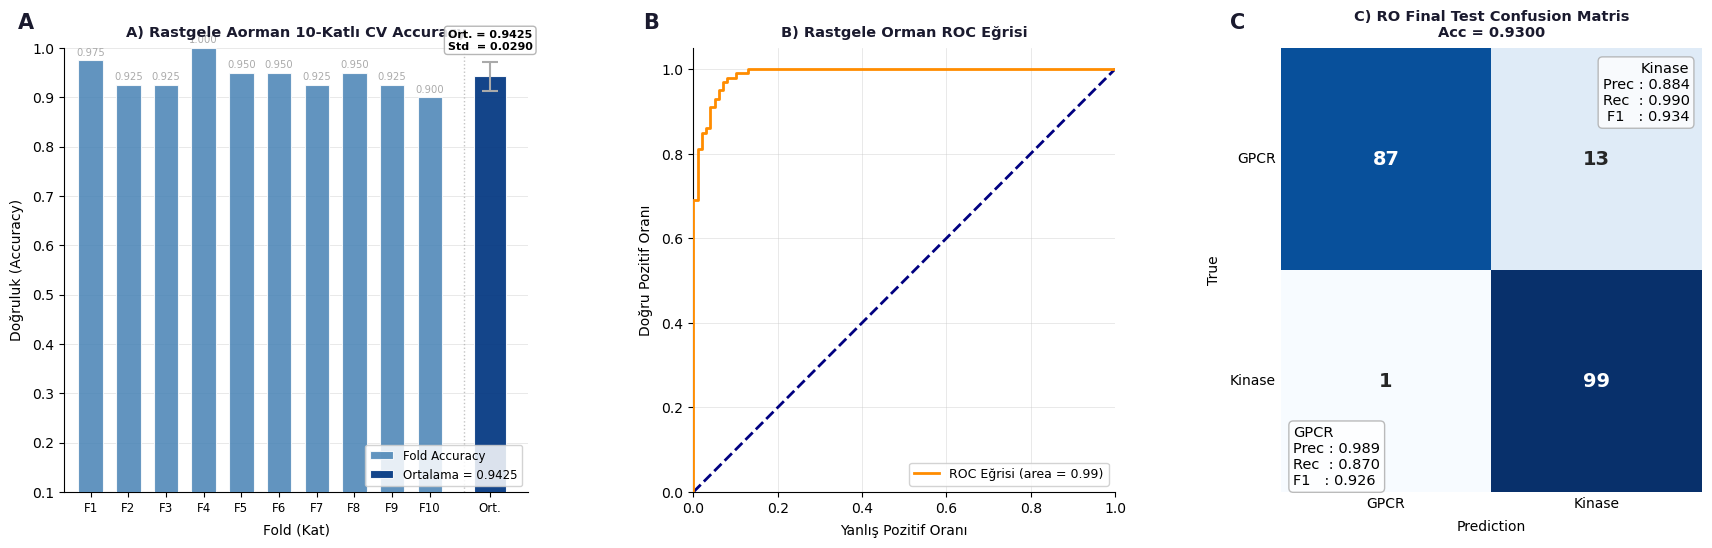

In [11]:
# =============================================================================
# RANDOM FOREST SONUÇ GÖRSELLEŞTİRME  

#   Panel A : 10-Katlı CV Accuracy + Ort. Acc. çubuk dağılımı
#   Panel B : ROC Eğrisi
#   Panel C : Final Test Karışıklık Matrisi
#   Gerekli değişkenler: cv_scores, final_rf, X_test, y_test, test_metrics, cm,
#                        CLASS_NAMES, acc
# =============================================================================

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import roc_curve, auc

matplotlib.rcParams.update({
    "font.family"       : "DejaVu Sans",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.color"        : "#CCCCCC",
    "grid.linewidth"    : 0.5,
    "grid.alpha"        : 0.6,
})

fig = plt.figure(figsize=(18, 6), facecolor="white")
fig.subplots_adjust(left=0.06, right=0.97, top=0.88, bottom=0.14, wspace=0.38)
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1.1, 1, 1])

ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])
ax_c = fig.add_subplot(gs[2])

PANEL_LABEL = dict(fontsize=15, fontweight="bold", color="#1A1A2E", ha="left", va="top")

# =============================================================================
# PANEL A — 10-Katlı CV Accuracy Çubuk Dağılımı
# =============================================================================
fold_accs = [s[0] for s in cv_scores]
n_folds  = len(fold_accs)
mean_acc = np.mean(fold_accs)
std_acc  = np.std(fold_accs, ddof=1)

fold_x = np.arange(1, n_folds + 1)
mean_x = n_folds + 1.6
C_MEAN_BAR = "#003580"

ax_a.bar(fold_x, fold_accs, color="steelblue", width=0.65, edgecolor="white",
         linewidth=0.8, zorder=3, alpha=0.85, label="Fold Accuracy")
ax_a.bar(mean_x, mean_acc, color=C_MEAN_BAR, width=0.85, edgecolor="white",
         linewidth=0.8, zorder=3, alpha=0.92, label=f"Ortalama = {mean_acc:.4f}")
ax_a.errorbar(mean_x, mean_acc, yerr=std_acc, fmt="none", color="#AAAAAA",
              capsize=6, capthick=1.5, linewidth=1.5, zorder=5)

for xi, val in zip(fold_x, fold_accs):
    ax_a.text(xi, val + 0.006, f"{val:.3f}", ha="center", va="bottom",
              fontsize=7.2, color="#AAAAAA")

props_a = dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="#AAAAAA")
ax_a.text(mean_x, mean_acc + std_acc + 0.022,
          f"Ort. = {mean_acc:.4f}\nStd  = {std_acc:.4f}",
          ha="center", va="bottom", fontsize=8, color="black",
          fontweight="semibold", bbox=props_a, zorder=6)

ax_a.axvline(n_folds + 0.9, color="#AAAAAA", linewidth=1.0, linestyle=":",
             alpha=0.7, zorder=2)

all_x = list(fold_x) + [mean_x]
tick_lbls = [f"F{i}" for i in range(1, n_folds + 1)] + ["Ort."]
ax_a.set_xticks(all_x)
ax_a.set_xticklabels(tick_lbls, fontsize=8.5)
ax_a.set_xlabel("Fold (Kat)", fontsize=10, labelpad=6)
ax_a.set_ylabel("Doğruluk (Accuracy)", fontsize=10, labelpad=6)
ax_a.set_ylim(0.10, 1.00)
ax_a.set_xlim(0.3, n_folds + 2.6)
ax_a.legend(fontsize=8.5, loc="lower right", framealpha=0.85)
ax_a.grid(axis="x", alpha=0)
ax_a.text(-0.10, 1.08, "A", transform=ax_a.transAxes, **PANEL_LABEL)
ax_a.set_title("A) Rastgele Aorman 10-Katlı CV Accuracy",
               fontsize=10.5, fontweight="semibold", pad=8, color="#1A1A2E")

# =============================================================================
# PANEL B — ROC Eğrisi
# =============================================================================
prob_test = final_rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, prob_test, pos_label=1)
roc_auc = auc(fpr, tpr)

ax_b.plot(fpr, tpr, color="darkorange", lw=2,
          label=f"ROC Eğrisi (area = {roc_auc:.2f})", zorder=4)
ax_b.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", zorder=3)
ax_b.set_xlim([0.0, 1.0]); ax_b.set_ylim([0.0, 1.05])
ax_b.set_xlabel("Yanlış Pozitif Oranı", fontsize=10, labelpad=6)
ax_b.set_ylabel("Doğru Pozitif Oranı", fontsize=10, labelpad=6)
ax_b.legend(loc="lower right", fontsize=9, framealpha=0.85)
ax_b.text(-0.12, 1.08, "B", transform=ax_b.transAxes, **PANEL_LABEL)
ax_b.set_title("B) Rastgele Orman ROC Eğrisi",
               fontsize=10.5, fontweight="semibold", pad=8, color="#1A1A2E")

# =============================================================================
# PANEL C — Karışıklık Matrisi
# =============================================================================
props = dict(boxstyle="round", facecolor="white", alpha=0.80, edgecolor="#AAAAAA")
m_gpcr, m_kinase = test_metrics["GPCR"], test_metrics["Kinase"]
text_gpcr = (f"GPCR\nPrec : {m_gpcr['precision']:.3f}\n"
             f"Rec  : {m_gpcr['recall']:.3f}\nF1   : {m_gpcr['f1']:.3f}")
text_kinase = (f"Kinase\nPrec : {m_kinase['precision']:.3f}\n"
               f"Rec  : {m_kinase['recall']:.3f}\nF1   : {m_kinase['f1']:.3f}")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax_c,
            linewidths=0, annot_kws={"size": 14, "weight": "bold"})
ax_c.grid(False)
for _, spine in ax_c.spines.items():
    spine.set_visible(False)
ax_c.set_xlabel("Prediction", fontsize=10, labelpad=6)
ax_c.set_ylabel("True", fontsize=10, labelpad=6)
ax_c.set_xticklabels(CLASS_NAMES, fontsize=10)
ax_c.set_yticklabels(CLASS_NAMES, fontsize=10, rotation=0)
ax_c.tick_params(length=0)
ax_c.set_title(f"C) RO Final Test Confusion Matris\nAcc = {acc:.4f}",
               fontsize=10.5, fontweight="semibold", pad=8, color="#1A1A2E")
ax_c.text(0.03, 0.15, text_gpcr, transform=ax_c.transAxes, ha="left", va="top",
          fontsize=10.5, bbox=props)
ax_c.text(0.97, 0.97, text_kinase, transform=ax_c.transAxes, ha="right", va="top",
          fontsize=10.5, bbox=props)
ax_c.text(-0.12, 1.08, "C", transform=ax_c.transAxes, **PANEL_LABEL)

fig.savefig("rf_sonuc_grafik.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()